In [ ]:
import os
import sys
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split


THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR
TAGGING_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..'))
DATA_DIR = os.path.abspath(os.path.join(TAGGING_DIR, '..'))

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
import model as model_mod  # noqa: E402
import importlib  # noqa: E402
importlib.reload(tool)  # noqa: E402
importlib.reload(model_mod)  # noqa: E402
from model import ParticleTransformerKD, SharedEncoderUnsmearClassifier  # noqa: E402

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

RUN_NAME = 'unsmear_transformer_sharedencoder0324_feat_weight_repeat3_externalbaseline'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')
GRAD_PROBE_DIR = os.path.join(OUT_DIR, 'grad_probe')
METRICS_DIR = os.path.join(OUT_DIR, 'metrics')
REPEAT_DIR = os.path.join(OUT_DIR, 'repeats')
TABLE_DIR = os.path.join(OUT_DIR, 'tables')
EXTERNAL_BASELINE_RUN_DIR = os.path.join(TAGGING_DIR, 'Baseline_smearing', 'runs', 'smear_only_offline_hlt_hltkd_repeat3')
EXTERNAL_BASELINE_REPEAT_DIR = os.path.join(EXTERNAL_BASELINE_RUN_DIR, 'repeats')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)
tool.ensure_dir(GRAD_PROBE_DIR)
tool.ensure_dir(METRICS_DIR)
tool.ensure_dir(REPEAT_DIR)
tool.ensure_dir(TABLE_DIR)

CONFIG = {
    'data_path': os.path.join(DATA_DIR, 'test.h5'),
    'n_jets': 200000,
    'max_particles': 100,
    'feature_kind': '7d',
    'repeat_seeds': [42, 52, 62],
    'kd_teacher_repeat_seed': 62,
    'external_baseline_repeat_dir': EXTERNAL_BASELINE_REPEAT_DIR,
    'load_joint_model': True,
    'joint_model': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 6,
        'ff_dim': 512,
        'dropout': 0.1,
        'unsmear_decoder_layers': 2,
        'unsmear_decoder_heads': 8,
        'unsmear_decoder_ff_dim': 512,
        'unsmear_decoder_dropout': 0.1,
        'return_reco': True,
        'add_mask_channel': False,
        'mask_output': True,
        'use_positional_embedding': False,
        'max_seq_len': 128,
    },
    'hlt_effects': {
        'pt_threshold_offline': 0,
        'pt_threshold_hlt': 0,
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
    },
    'tagger': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 6,
        'ff_dim': 512,
        'dropout': 0.1,
    },
    'kd': {
        'enable': True,
        'temperature': 2.0,
        'alpha_kd': 0.5,
        'alpha_attn': 0,
    },
    'training': {
        'batch_size': 256,
        'epochs': 50,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 3,
        'patience': 8,
        'early_stop_metric': 'val_auc_weighted',
        'use_sample_weight_for_all_losses': True,
        'joint_unsmear_weight': 2.4,
        'joint_cls_weight': 0.6,
        'joint_phys_weight': 0.0,
        'feature_loss_weights': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
        'resmear_each_epoch_joint': True,
        'resmear_seed_stride': 1,
    },
    'grad_probe': {
        'train_batches_per_epoch': 100,
        'val_batches_per_epoch': 20,
    },
}

feat_names = tool.get_feat_names(CONFIG['feature_kind'])
CONFIG['joint_model']['input_dim'] = len(feat_names)
CONFIG['joint_model']['max_seq_len'] = int(CONFIG['max_particles'])
CONFIG['tagger']['input_dim'] = len(feat_names)

feature_loss_weights = np.asarray(CONFIG['training']['feature_loss_weights'], dtype=np.float32)
if feature_loss_weights.shape[0] != len(feat_names):
    raise ValueError(
        f"Expected {len(feat_names)} feature weights for {CONFIG['feature_kind']}, got {feature_loss_weights.shape[0]}"
    )
CONFIG['training']['feature_loss_weights'] = feature_loss_weights.tolist()
CONFIG['training']['use_sample_weight_for_all_losses'] = bool(
    CONFIG['training'].get('use_sample_weight_for_all_losses', True)
)

config_path = os.path.join(OUT_DIR, 'config.json')
tool.save_config(CONFIG, config_path)
print('Data path:', CONFIG['data_path'])
print('Run dir:', OUT_DIR)
print('Feature kind:', CONFIG['feature_kind'], 'feat_names:', feat_names)
print('Repeat seeds:', CONFIG['repeat_seeds'])
print('KD teacher repeat seed:', CONFIG['kd_teacher_repeat_seed'])
print('External baseline repeat dir:', CONFIG['external_baseline_repeat_dir'])
print('Feature loss weights:', dict(zip(feat_names, np.round(feature_loss_weights, 4))))
print('Joint physical consistency weight:', float(CONFIG['training']['joint_phys_weight']))
print('Use sample weight for all losses:', bool(CONFIG['training']['use_sample_weight_for_all_losses']))


In [3]:
# Load the raw constituents and build the offline / HLT views
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)
mask_raw = pt > 0
print('Raw:', constituents_raw.shape, 'mask:', mask_raw.shape)
print('Signal:', int(labels.sum()), 'Bkg:', int((1 - labels).sum()))

hcfg = tool.HLTEffectsCfg(**CONFIG['hlt_effects'])
_, hlt_const, hlt_mask = tool.apply_hlt_effects_pair(
    constituents_raw,
    mask_raw,
    hcfg,
    seed=seed,
)

pt_thr_off = float(CONFIG['hlt_effects']['pt_threshold_offline'])
off_mask = mask_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
off_const = constituents_raw.copy()
off_const[~off_mask] = 0.0
hlt_const = hlt_const.copy()
hlt_const[~hlt_mask] = 0.0

axis_off = tool.compute_jet_axis(off_const, off_mask)
axis_hlt = tool.compute_jet_axis(hlt_const, hlt_mask)
feat_off = tool.compute_features_with_axis(off_const, off_mask, axis_off, kind=CONFIG['feature_kind'])
feat_hlt = tool.compute_features_with_axis(hlt_const, hlt_mask, axis_hlt, kind=CONFIG['feature_kind'])

idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=seed, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=seed, stratify=labels[temp_idx])
print(f'Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}')

feat_means, feat_stds = tool.get_stats(feat_off, off_mask, train_idx)
feat_off_std = tool.standardize(feat_off, off_mask, feat_means, feat_stds, clip=10.0)
feat_hlt_std = tool.standardize(feat_hlt, hlt_mask, feat_means, feat_stds, clip=10.0)
common_mask = off_mask & hlt_mask

x_joint = feat_hlt_std.copy()
y_joint = feat_off_std.copy()
x_joint[~common_mask] = 0.0
y_joint[~common_mask] = 0.0

train_const_raw = constituents_raw[train_idx]
train_mask_raw = mask_raw[train_idx]

print('Offline/HLT feature shape:', feat_off_std.shape, feat_hlt_std.shape)
print('Mask identical:', bool(np.array_equal(off_mask, hlt_mask)))
print('Common-mask fraction:', float(common_mask.mean()))
print('Feat means:', np.round(feat_means, 4))
print('Feat stds :', np.round(feat_stds, 4))
print('Baseline epoch resmear enabled:', bool(CONFIG['training'].get('resmear_each_epoch_baselines', False)))
print('Joint epoch resmear enabled:', bool(CONFIG['training'].get('resmear_each_epoch_joint', False)))


Raw: (200000, 100, 4) mask: (200000, 100)
Signal: 99836 Bkg: 100164
Split: train=140,000 val=30,000 test=30,000
Offline/HLT feature shape: (200000, 100, 7) (200000, 100, 7)
Mask identical: True
Common-mask fraction: 0.5429243
Feat means: [-2.0000e-04 -1.0000e-04  8.7940e+00  9.0840e+00 -5.2585e+00 -5.2701e+00
  2.2250e-01]
Feat stds : [0.2121 0.2173 1.5182 1.5217 1.4919 1.4935 0.2067]
Baseline epoch resmear enabled: True
Joint epoch resmear enabled: True


In [4]:
# Build the datasets and loaders
BS = int(CONFIG['training']['batch_size'])
train_ds_hlt = tool.JetDataset(
    feat_off_std[train_idx],
    feat_hlt_std[train_idx],
    labels[train_idx],
    off_mask[train_idx],
    hlt_mask[train_idx],
    weights[train_idx],
)
val_ds_hlt = tool.JetDataset(
    feat_off_std[val_idx],
    feat_hlt_std[val_idx],
    labels[val_idx],
    off_mask[val_idx],
    hlt_mask[val_idx],
    weights[val_idx],
)
test_ds_hlt = tool.JetDataset(
    feat_off_std[test_idx],
    feat_hlt_std[test_idx],
    labels[test_idx],
    off_mask[test_idx],
    hlt_mask[test_idx],
    weights[test_idx],
)

train_ds_joint = tool.JointJetDataset(
    x_joint[train_idx],
    y_joint[train_idx],
    common_mask[train_idx],
    labels[train_idx],
    weights[train_idx],
)
val_ds_joint = tool.JointJetDataset(
    x_joint[val_idx],
    y_joint[val_idx],
    common_mask[val_idx],
    labels[val_idx],
    weights[val_idx],
)
test_ds_joint = tool.JointJetDataset(
    x_joint[test_idx],
    y_joint[test_idx],
    common_mask[test_idx],
    labels[test_idx],
    weights[test_idx],
)

train_loader_hlt = DataLoader(train_ds_hlt, batch_size=BS, shuffle=True, drop_last=True)
val_loader_hlt = DataLoader(val_ds_hlt, batch_size=BS, shuffle=False)
test_loader_hlt = DataLoader(test_ds_hlt, batch_size=BS, shuffle=False)

train_loader_joint = DataLoader(train_ds_joint, batch_size=BS, shuffle=True, drop_last=True)
val_loader_joint = DataLoader(val_ds_joint, batch_size=BS, shuffle=False)
test_loader_joint = DataLoader(test_ds_joint, batch_size=BS, shuffle=False)


def make_epoch_hlt_train_loader(epoch: int):
    return tool.make_epoch_hlt_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        feat_off_train=feat_off_std[train_idx],
        off_mask_train=off_mask[train_idx],
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=seed,
        fixed_feat_hlt_train=feat_hlt_std[train_idx],
        fixed_hlt_mask_train=hlt_mask[train_idx],
        seed_stride=int(CONFIG['training'].get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(CONFIG['training'].get('resmear_each_epoch_baselines', False)),
        clip=10.0,
    )


def make_epoch_joint_train_loader(epoch: int):
    return tool.make_epoch_joint_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=seed,
        fixed_x_train=x_joint[train_idx],
        fixed_y_train=y_joint[train_idx],
        fixed_mask_train=common_mask[train_idx],
        seed_stride=int(CONFIG['training'].get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(CONFIG['training'].get('resmear_each_epoch_joint', True)),
        clip=10.0,
    )


In [ ]:
# Load external baseline models/results and repeat-train the local joint shared-encoder models
train_cfg = CONFIG['training']
kd_cfg = CONFIG['kd']
grad_probe_cfg = CONFIG.get('grad_probe', {})
use_sample_weight_for_all_losses = bool(train_cfg.get('use_sample_weight_for_all_losses', True))
joint_feature_loss_weights = np.asarray(train_cfg['feature_loss_weights'], dtype=np.float32)
REPEAT_SEEDS = [int(x) for x in CONFIG.get('repeat_seeds', [42, 52, 62])]
REPRESENTATIVE_REPEAT_SEED = int(REPEAT_SEEDS[0])
KD_TEACHER_REPEAT_SEED = int(CONFIG.get('kd_teacher_repeat_seed', 62))
BASELINE_REPEAT_ROOT = str(CONFIG.get('external_baseline_repeat_dir', EXTERNAL_BASELINE_REPEAT_DIR))
JOINT_REPEAT_DIR = os.path.join(OUT_DIR, 'repeats')
JOINT_REPEAT_TABLE_DIR = os.path.join(OUT_DIR, 'tables')
JOINT_REPEAT_FIG_DIR = os.path.join(OUT_DIR, 'figs')
tool.ensure_dir(JOINT_REPEAT_DIR)
tool.ensure_dir(JOINT_REPEAT_TABLE_DIR)
tool.ensure_dir(JOINT_REPEAT_FIG_DIR)

EXTERNAL_BASELINE_FILES = {
    'Teacher(OFF_FULL)': {
        'ckpt': 'offline_teacher.pt',
        'pred': 'offline_teacher_test_preds.npz',
    },
    'Student(HLT)': {
        'ckpt': 'hlt_baseline.pt',
        'pred': 'hlt_baseline_test_preds.npz',
    },
    'Student(HLT)+KD': {
        'ckpt': 'hlt_kd_student.pt',
        'pred': 'hlt_kd_student_test_preds.npz',
    },
}


def _set_repeat_seed(seed_value: int):
    np.random.seed(int(seed_value))
    torch.manual_seed(int(seed_value))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed_value))



def _find_external_repeat_dir(repeat_seed: int) -> str:
    if not os.path.isdir(BASELINE_REPEAT_ROOT):
        raise FileNotFoundError(f'External baseline repeat dir not found: {BASELINE_REPEAT_ROOT}')
    suffix = f'seed_{int(repeat_seed)}'
    matches = []
    for name in sorted(os.listdir(BASELINE_REPEAT_ROOT)):
        full = os.path.join(BASELINE_REPEAT_ROOT, name)
        if os.path.isdir(full) and name.endswith(suffix):
            matches.append(full)
    if not matches:
        raise FileNotFoundError(f'Cannot find external repeat dir for seed={repeat_seed} under {BASELINE_REPEAT_ROOT}')
    if len(matches) > 1:
        raise RuntimeError(f'Multiple external repeat dirs matched seed={repeat_seed}: {matches}')
    return matches[0]



def _load_external_baseline_result(repeat_seed: int, model_name: str) -> dict:
    repeat_dir = _find_external_repeat_dir(int(repeat_seed))
    spec = EXTERNAL_BASELINE_FILES[str(model_name)]
    ckpt_path = os.path.join(repeat_dir, 'ckpts', spec['ckpt'])
    pred_path = os.path.join(repeat_dir, 'predictions', spec['pred'])
    if not os.path.isfile(pred_path):
        raise FileNotFoundError(f'External prediction bundle missing: {pred_path}')
    bundle = np.load(pred_path)
    preds = np.asarray(bundle['preds'], dtype=np.float32)
    labels_eval = np.asarray(bundle['labels'], dtype=np.float32)
    weights_eval = np.asarray(bundle['weights'], dtype=np.float32) if 'weights' in bundle.files else np.ones_like(labels_eval, dtype=np.float32)
    sample_weight = weights_eval if use_sample_weight_for_all_losses else None
    fpr, tpr, auc, auc_weighted = tool.compute_roc(labels_eval, preds, sample_weight=sample_weight)
    print(f'Loaded external baseline result: seed={repeat_seed} model={model_name}')
    return {
        'model': str(model_name),
        'source': 'external_baseline',
        'repeat_seed': int(repeat_seed),
        'auc': float(auc),
        'auc_weighted': float(auc_weighted),
        'fpr': fpr,
        'tpr': tpr,
        'preds': preds,
        'labels': labels_eval,
        'weights': weights_eval,
        'ckpt_path': ckpt_path,
        'prediction_path': pred_path,
    }



def _load_kd_teacher_from_external_repeat(repeat_seed: int):
    teacher_model = ParticleTransformerKD(**CONFIG['tagger']).to(device)
    repeat_dir = _find_external_repeat_dir(int(repeat_seed))
    ckpt_path = os.path.join(repeat_dir, 'ckpts', EXTERNAL_BASELINE_FILES['Teacher(OFF_FULL)']['ckpt'])
    if not os.path.isfile(ckpt_path):
        raise FileNotFoundError(f'KD teacher checkpoint missing: {ckpt_path}')
    tool.load_checkpoint(teacher_model, ckpt_path, map_location=device)
    teacher_model.eval()
    return teacher_model, ckpt_path



def _make_repeat_joint_train_loader(epoch: int, repeat_seed: int):
    return tool.make_epoch_joint_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=int(repeat_seed),
        fixed_x_train=x_joint[train_idx],
        fixed_y_train=y_joint[train_idx],
        fixed_mask_train=common_mask[train_idx],
        seed_stride=int(train_cfg.get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(train_cfg.get('resmear_each_epoch_joint', True)),
        clip=10.0,
    )


teacher_for_kd, teacher_for_kd_ckpt = _load_kd_teacher_from_external_repeat(KD_TEACHER_REPEAT_SEED)
print('KD teacher checkpoint:', teacher_for_kd_ckpt)
print('Joint repeat seeds:', REPEAT_SEEDS)

repeat_results = []
representative_repeat_result = None
REPRESENTATIVE_GRAD_PROBE_DIR = None

for repeat_idx, repeat_seed in enumerate(REPEAT_SEEDS):
    print()
    print(f'==== Joint repeat {repeat_idx + 1}/{len(REPEAT_SEEDS)} seed={repeat_seed} ====')
    _set_repeat_seed(int(repeat_seed))

    repeat_dir = os.path.join(JOINT_REPEAT_DIR, f'repeat_{int(repeat_idx):02d}_seed_{int(repeat_seed)}')
    repeat_ckpt_dir = os.path.join(repeat_dir, 'ckpts')
    repeat_pred_dir = os.path.join(repeat_dir, 'predictions')
    repeat_metrics_dir = os.path.join(repeat_dir, 'metrics')
    repeat_grad_probe_dir = os.path.join(repeat_dir, 'grad_probe')
    tool.ensure_dir(repeat_dir)
    tool.ensure_dir(repeat_ckpt_dir)
    tool.ensure_dir(repeat_pred_dir)
    tool.ensure_dir(repeat_metrics_dir)
    tool.ensure_dir(repeat_grad_probe_dir)

    repeat_model_results = {}
    for external_name in ['Teacher(OFF_FULL)', 'Student(HLT)', 'Student(HLT)+KD']:
        repeat_model_results[external_name] = _load_external_baseline_result(int(repeat_seed), external_name)

    repeat_joint_loader_factory = (
        (lambda epoch, repeat_seed=repeat_seed: _make_repeat_joint_train_loader(epoch, repeat_seed=int(repeat_seed)))
        if bool(train_cfg.get('resmear_each_epoch_joint', True))
        else None
    )

    grad_probe_joint_no_kd = {
        'model_name': 'joint_no_kd',
        'output_prefix': os.path.join(repeat_grad_probe_dir, 'joint_no_kd'),
        'train_batches_per_epoch': int(grad_probe_cfg.get('train_batches_per_epoch', 100)),
        'val_batches_per_epoch': int(grad_probe_cfg.get('val_batches_per_epoch', 20)),
    }
    grad_probe_joint_with_kd = {
        'model_name': 'joint_with_kd',
        'output_prefix': os.path.join(repeat_grad_probe_dir, 'joint_with_kd'),
        'train_batches_per_epoch': int(grad_probe_cfg.get('train_batches_per_epoch', 100)),
        'val_batches_per_epoch': int(grad_probe_cfg.get('val_batches_per_epoch', 20)),
    }

    joint_model_no_kd = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
    joint_ckpt_no_kd = os.path.join(repeat_ckpt_dir, 'joint_sharedencoder_no_kd.pt')
    joint_metrics_no_kd = os.path.join(repeat_metrics_dir, 'joint_no_kd_epoch_metrics.csv')
    joint_model_no_kd = tool.train_or_load_joint_model(
        'JointSharedEncoder(HLT,no_kd)',
        joint_model_no_kd,
        joint_ckpt_no_kd,
        train_loader_joint,
        val_loader_joint,
        device=device,
        feat_names=feat_names,
        feat_means=feat_means,
        feat_stds=feat_stds,
        feature_loss_weights=joint_feature_loss_weights,
        joint_phys_weight=float(train_cfg['joint_phys_weight']),
        joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
        joint_cls_weight=float(train_cfg['joint_cls_weight']),
        lr=float(train_cfg['lr']),
        weight_decay=float(train_cfg['weight_decay']),
        warmup_epochs=int(train_cfg['warmup_epochs']),
        epochs=int(train_cfg['epochs']),
        patience=int(train_cfg['patience']),
        early_stop_metric=str(train_cfg['early_stop_metric']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
        teacher=teacher_for_kd,
        use_kd=False,
        kd_temperature=float(kd_cfg['temperature']),
        kd_alpha=float(kd_cfg['alpha_kd']),
        kd_alpha_attn=float(kd_cfg['alpha_attn']),
        allow_load=bool(CONFIG.get('load_joint_model', False)),
        train_loader_factory=repeat_joint_loader_factory,
        grad_probe_cfg=grad_probe_joint_no_kd,
        epoch_metrics_path=joint_metrics_no_kd,
    )
    joint_test_no_kd = tool.eval_joint_model(
        joint_model_no_kd,
        test_loader_joint,
        device=device,
        feat_names=feat_names,
        feat_means=feat_means,
        feat_stds=feat_stds,
        feature_loss_weights=joint_feature_loss_weights,
        joint_phys_weight=float(train_cfg['joint_phys_weight']),
        joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
        joint_cls_weight=float(train_cfg['joint_cls_weight']),
        teacher=teacher_for_kd,
        use_kd=False,
        kd_temperature=float(kd_cfg['temperature']),
        kd_alpha=float(kd_cfg['alpha_kd']),
        kd_alpha_attn=float(kd_cfg['alpha_attn']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    )
    joint_pred_no_kd = os.path.join(repeat_pred_dir, 'joint_sharedencoder_no_kd_test_preds.npz')
    tool.save_prediction_bundle(
        joint_pred_no_kd,
        preds=np.asarray(joint_test_no_kd['preds'], dtype=np.float32),
        labels=np.asarray(joint_test_no_kd['labels'], dtype=np.float32),
        weights=np.asarray(joint_test_no_kd['weights'], dtype=np.float32),
    )
    repeat_model_results['JointSharedEncoder(HLT,no_kd)'] = {
        'model': 'JointSharedEncoder(HLT,no_kd)',
        'source': 'local_joint',
        'repeat_seed': int(repeat_seed),
        'auc': float(joint_test_no_kd['auc']),
        'auc_weighted': float(joint_test_no_kd['auc_weighted']),
        'preds': np.asarray(joint_test_no_kd['preds'], dtype=np.float32),
        'labels': np.asarray(joint_test_no_kd['labels'], dtype=np.float32),
        'weights': np.asarray(joint_test_no_kd['weights'], dtype=np.float32),
        'ckpt_path': joint_ckpt_no_kd,
        'prediction_path': joint_pred_no_kd,
        'epoch_metrics_path': joint_metrics_no_kd,
        'grad_probe_prefix': grad_probe_joint_no_kd['output_prefix'],
        'test_metrics': joint_test_no_kd,
    }

    joint_model_with_kd = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
    joint_ckpt_with_kd = os.path.join(repeat_ckpt_dir, 'joint_sharedencoder_with_kd.pt')
    joint_metrics_with_kd = os.path.join(repeat_metrics_dir, 'joint_with_kd_epoch_metrics.csv')
    joint_model_with_kd = tool.train_or_load_joint_model(
        'JointSharedEncoder(HLT,with_kd)',
        joint_model_with_kd,
        joint_ckpt_with_kd,
        train_loader_joint,
        val_loader_joint,
        device=device,
        feat_names=feat_names,
        feat_means=feat_means,
        feat_stds=feat_stds,
        feature_loss_weights=joint_feature_loss_weights,
        joint_phys_weight=float(train_cfg['joint_phys_weight']),
        joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
        joint_cls_weight=float(train_cfg['joint_cls_weight']),
        lr=float(train_cfg['lr']),
        weight_decay=float(train_cfg['weight_decay']),
        warmup_epochs=int(train_cfg['warmup_epochs']),
        epochs=int(train_cfg['epochs']),
        patience=int(train_cfg['patience']),
        early_stop_metric=str(train_cfg['early_stop_metric']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
        teacher=teacher_for_kd,
        use_kd=True,
        kd_temperature=float(kd_cfg['temperature']),
        kd_alpha=float(kd_cfg['alpha_kd']),
        kd_alpha_attn=float(kd_cfg['alpha_attn']),
        allow_load=bool(CONFIG.get('load_joint_model', False)),
        train_loader_factory=repeat_joint_loader_factory,
        grad_probe_cfg=grad_probe_joint_with_kd,
        epoch_metrics_path=joint_metrics_with_kd,
    )
    joint_test_with_kd = tool.eval_joint_model(
        joint_model_with_kd,
        test_loader_joint,
        device=device,
        feat_names=feat_names,
        feat_means=feat_means,
        feat_stds=feat_stds,
        feature_loss_weights=joint_feature_loss_weights,
        joint_phys_weight=float(train_cfg['joint_phys_weight']),
        joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
        joint_cls_weight=float(train_cfg['joint_cls_weight']),
        teacher=teacher_for_kd,
        use_kd=True,
        kd_temperature=float(kd_cfg['temperature']),
        kd_alpha=float(kd_cfg['alpha_kd']),
        kd_alpha_attn=float(kd_cfg['alpha_attn']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    )
    joint_pred_with_kd = os.path.join(repeat_pred_dir, 'joint_sharedencoder_with_kd_test_preds.npz')
    tool.save_prediction_bundle(
        joint_pred_with_kd,
        preds=np.asarray(joint_test_with_kd['preds'], dtype=np.float32),
        labels=np.asarray(joint_test_with_kd['labels'], dtype=np.float32),
        weights=np.asarray(joint_test_with_kd['weights'], dtype=np.float32),
    )
    repeat_model_results['JointSharedEncoder(HLT,with_kd)'] = {
        'model': 'JointSharedEncoder(HLT,with_kd)',
        'source': 'local_joint_kd',
        'repeat_seed': int(repeat_seed),
        'auc': float(joint_test_with_kd['auc']),
        'auc_weighted': float(joint_test_with_kd['auc_weighted']),
        'preds': np.asarray(joint_test_with_kd['preds'], dtype=np.float32),
        'labels': np.asarray(joint_test_with_kd['labels'], dtype=np.float32),
        'weights': np.asarray(joint_test_with_kd['weights'], dtype=np.float32),
        'ckpt_path': joint_ckpt_with_kd,
        'prediction_path': joint_pred_with_kd,
        'epoch_metrics_path': joint_metrics_with_kd,
        'grad_probe_prefix': grad_probe_joint_with_kd['output_prefix'],
        'test_metrics': joint_test_with_kd,
    }

    repeat_results.append({
        'repeat_idx': int(repeat_idx),
        'repeat_seed': int(repeat_seed),
        'models': repeat_model_results,
        'repeat_dir': repeat_dir,
    })

    if int(repeat_seed) == int(REPRESENTATIVE_REPEAT_SEED):
        representative_repeat_result = repeat_results[-1]
        REPRESENTATIVE_GRAD_PROBE_DIR = repeat_grad_probe_dir
        teacher = teacher_for_kd
        teacher_ckpt = teacher_for_kd_ckpt
        joint_ckpt_no_kd = joint_ckpt_no_kd
        joint_ckpt_with_kd = joint_ckpt_with_kd
        joint_model_no_kd = joint_model_no_kd
        joint_model_with_kd = joint_model_with_kd
        joint_test_no_kd = joint_test_no_kd
        joint_test_with_kd = joint_test_with_kd

if representative_repeat_result is None:
    raise RuntimeError(f'Failed to locate representative repeat seed={REPRESENTATIVE_REPEAT_SEED}')

print()
print('Completed joint repeats:', len(repeat_results))
print('Representative repeat seed:', REPRESENTATIVE_REPEAT_SEED)
print('Representative grad probe dir:', REPRESENTATIVE_GRAD_PROBE_DIR)


In [ ]:
import pandas as pd

use_sample_weight_for_all_losses = bool(train_cfg.get('use_sample_weight_for_all_losses', True))
MODEL_DISPLAY_ORDER = [
    'Teacher(OFF_FULL)',
    'Student(HLT)',
    'Student(HLT)+KD',
    'JointSharedEncoder(HLT,no_kd)',
    'JointSharedEncoder(HLT,with_kd)',
]
MODEL_COLORS = {
    'Teacher(OFF_FULL)': '#4C78A8',
    'Student(HLT)': '#F58518',
    'Student(HLT)+KD': '#54A24B',
    'JointSharedEncoder(HLT,no_kd)': '#E45756',
    'JointSharedEncoder(HLT,with_kd)': '#72B7B2',
}


def _gap_recovery(model_fpr: float, baseline_fpr: float, teacher_fpr: float) -> float:
    denom = float(baseline_fpr - teacher_fpr)
    if abs(denom) < 1e-12:
        return float('nan')
    return float((baseline_fpr - model_fpr) / denom)


joint_repeat_detail_rows = []
for repeat_result in repeat_results:
    repeat_seed = int(repeat_result['repeat_seed'])
    teacher_result = repeat_result['models']['Teacher(OFF_FULL)']
    baseline_result = repeat_result['models']['Student(HLT)']
    teacher_weight = np.asarray(teacher_result['weights'], dtype=np.float64) if use_sample_weight_for_all_losses else None
    baseline_weight = np.asarray(baseline_result['weights'], dtype=np.float64) if use_sample_weight_for_all_losses else None
    teacher_fpr, teacher_tpr, _, _ = tool.compute_roc(
        np.asarray(teacher_result['labels'], dtype=np.float32),
        np.asarray(teacher_result['preds'], dtype=np.float32),
        sample_weight=teacher_weight,
    )
    baseline_fpr, baseline_tpr, _, _ = tool.compute_roc(
        np.asarray(baseline_result['labels'], dtype=np.float32),
        np.asarray(baseline_result['preds'], dtype=np.float32),
        sample_weight=baseline_weight,
    )
    teacher_fpr_30 = tool.fpr_at_target_tpr(teacher_tpr, teacher_fpr, 0.30)
    teacher_fpr_50 = tool.fpr_at_target_tpr(teacher_tpr, teacher_fpr, 0.50)
    baseline_fpr_30 = tool.fpr_at_target_tpr(baseline_tpr, baseline_fpr, 0.30)
    baseline_fpr_50 = tool.fpr_at_target_tpr(baseline_tpr, baseline_fpr, 0.50)

    for model_name in MODEL_DISPLAY_ORDER:
        model_result = repeat_result['models'][model_name]
        model_weight = np.asarray(model_result['weights'], dtype=np.float64) if use_sample_weight_for_all_losses else None
        fpr, tpr, auc_raw, auc_weighted_raw = tool.compute_roc(
            np.asarray(model_result['labels'], dtype=np.float32),
            np.asarray(model_result['preds'], dtype=np.float32),
            sample_weight=model_weight,
        )
        fpr_30 = tool.fpr_at_target_tpr(tpr, fpr, 0.30)
        fpr_50 = tool.fpr_at_target_tpr(tpr, fpr, 0.50)
        joint_repeat_detail_rows.append({
            'repeat_seed': int(repeat_seed),
            'model': str(model_name),
            'auc': float(model_result.get('auc', auc_raw)),
            'auc_weighted': float(model_result.get('auc_weighted', auc_weighted_raw)),
            'fpr_at_tpr30': float(fpr_30),
            'fpr_at_tpr50': float(fpr_50),
            'gap_recovery_tpr30': float(_gap_recovery(fpr_30, baseline_fpr_30, teacher_fpr_30)),
            'gap_recovery_tpr50': float(_gap_recovery(fpr_50, baseline_fpr_50, teacher_fpr_50)),
            'ckpt_path': str(model_result.get('ckpt_path', '')),
            'prediction_path': str(model_result.get('prediction_path', '')),
        })

joint_repeat_detail_df = pd.DataFrame(joint_repeat_detail_rows)
joint_repeat_summary_rows = []
for model_name in MODEL_DISPLAY_ORDER:
    df_model = joint_repeat_detail_df[joint_repeat_detail_df['model'] == str(model_name)].copy()
    if df_model.empty:
        continue
    joint_repeat_summary_rows.append({
        'model': str(model_name),
        'auc_mean': float(df_model['auc'].mean()),
        'auc_std': float(df_model['auc'].std(ddof=0)),
        'auc_weighted_mean': float(df_model['auc_weighted'].mean()),
        'auc_weighted_std': float(df_model['auc_weighted'].std(ddof=0)),
        'fpr_at_tpr30_mean': float(df_model['fpr_at_tpr30'].mean()),
        'fpr_at_tpr30_std': float(df_model['fpr_at_tpr30'].std(ddof=0)),
        'fpr_at_tpr50_mean': float(df_model['fpr_at_tpr50'].mean()),
        'fpr_at_tpr50_std': float(df_model['fpr_at_tpr50'].std(ddof=0)),
        'gap_recovery_tpr30_mean': float(df_model['gap_recovery_tpr30'].mean()),
        'gap_recovery_tpr30_std': float(df_model['gap_recovery_tpr30'].std(ddof=0)),
        'gap_recovery_tpr50_mean': float(df_model['gap_recovery_tpr50'].mean()),
        'gap_recovery_tpr50_std': float(df_model['gap_recovery_tpr50'].std(ddof=0)),
    })

joint_repeat_summary_df = pd.DataFrame(joint_repeat_summary_rows)
detail_csv = os.path.join(JOINT_REPEAT_TABLE_DIR, 'joint_repeat_detail.csv')
summary_csv = os.path.join(JOINT_REPEAT_TABLE_DIR, 'joint_repeat_summary.csv')
tool.save_rows_csv(detail_csv, joint_repeat_detail_rows)
tool.save_rows_csv(summary_csv, joint_repeat_summary_rows)
print('Saved table:', detail_csv)
print('Saved table:', summary_csv)

rep_models = representative_repeat_result['models']
rep_teacher = rep_models['Teacher(OFF_FULL)']
rep_hlt = rep_models['Student(HLT)']
rep_hlt_kd = rep_models['Student(HLT)+KD']
rep_joint_no_kd = rep_models['JointSharedEncoder(HLT,no_kd)']
rep_joint_with_kd = rep_models['JointSharedEncoder(HLT,with_kd)']

print(f"Representative Teacher(OFF_FULL) AUC={rep_teacher['auc']:.5f}, weighted AUC={rep_teacher['auc_weighted']:.5f}")
print(f"Representative Student(HLT) AUC={rep_hlt['auc']:.5f}, weighted AUC={rep_hlt['auc_weighted']:.5f}")
print(f"Representative Student(HLT)+KD AUC={rep_hlt_kd['auc']:.5f}, weighted AUC={rep_hlt_kd['auc_weighted']:.5f}")
print(f"Representative JointSharedEncoder(HLT,no_kd) AUC={rep_joint_no_kd['auc']:.5f}, weighted AUC={rep_joint_no_kd['auc_weighted']:.5f}")
print(f"Representative JointSharedEncoder(HLT,with_kd) AUC={rep_joint_with_kd['auc']:.5f}, weighted AUC={rep_joint_with_kd['auc_weighted']:.5f}")
print(f"Representative Joint(no_kd) test unsmear loss={rep_joint_no_kd['test_metrics']['unsmear_total']:.5f}")
print(f"Representative Joint(with_kd) test unsmear loss={rep_joint_with_kd['test_metrics']['unsmear_total']:.5f}")
print(f"Representative Joint(no_kd) test cls hard loss={rep_joint_no_kd['test_metrics']['cls_hard_total']:.5f}")
print(f"Representative Joint(with_kd) test cls hard loss={rep_joint_with_kd['test_metrics']['cls_hard_total']:.5f}")
print(f"Representative Joint(with_kd) test cls kd loss={rep_joint_with_kd['test_metrics']['cls_kd_total']:.5f}")
print(f"Representative Joint(with_kd) test cls attn loss={rep_joint_with_kd['test_metrics']['cls_attn_total']:.5f}")

common_tpr = np.linspace(0.0, 1.0, 401)
plt.figure(figsize=(7.4, 6.2))
for model_name in MODEL_DISPLAY_ORDER:
    roc_rows = []
    auc_values = []
    auc_weighted_values = []
    for repeat_result in repeat_results:
        model_result = repeat_result['models'][model_name]
        model_weight = np.asarray(model_result['weights'], dtype=np.float64) if use_sample_weight_for_all_losses else None
        fpr, tpr, auc_raw, auc_weighted_raw = tool.compute_roc(
            np.asarray(model_result['labels'], dtype=np.float32),
            np.asarray(model_result['preds'], dtype=np.float32),
            sample_weight=model_weight,
        )
        roc_rows.append(np.interp(common_tpr, tpr, fpr))
        auc_values.append(float(model_result.get('auc', auc_raw)))
        auc_weighted_values.append(float(model_result.get('auc_weighted', auc_weighted_raw)))
    roc_arr = np.asarray(roc_rows, dtype=np.float64)
    mean_fpr = roc_arr.mean(axis=0)
    std_fpr = roc_arr.std(axis=0)
    color = MODEL_COLORS.get(model_name, None)
    label = (
        f"{model_name} AUC={np.mean(auc_values):.4f}?{np.std(auc_values):.4f}, "
        f"wAUC={np.mean(auc_weighted_values):.4f}?{np.std(auc_weighted_values):.4f}"
    )
    plt.semilogy(common_tpr, np.clip(mean_fpr, 1e-6, 1.0), lw=2.0, color=color, label=label)
    plt.fill_between(
        common_tpr,
        np.clip(mean_fpr - std_fpr, 1e-6, 1.0),
        np.clip(mean_fpr + std_fpr, 1e-6, 1.0),
        color=color,
        alpha=0.12,
    )
plt.xlabel('True Positive Rate (Signal efficiency)')
plt.ylabel('False Positive Rate')
plt.title('Shared-encoder joint training ROC mean?std (test)')
plt.xlim(0.0, 1.0)
plt.ylim(1e-4, 1.0)
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
roc_out = os.path.join(JOINT_REPEAT_FIG_DIR, 'sharedencoder_joint_repeat_mean_roc_logfpr.png')
plt.savefig(roc_out, dpi=180, bbox_inches='tight')
print('Saved figure:', roc_out)
plt.show()

summary_display_df = joint_repeat_summary_df.copy()
for col in [
    'auc_mean', 'auc_std', 'auc_weighted_mean', 'auc_weighted_std',
    'fpr_at_tpr30_mean', 'fpr_at_tpr30_std', 'fpr_at_tpr50_mean', 'fpr_at_tpr50_std',
    'gap_recovery_tpr30_mean', 'gap_recovery_tpr30_std', 'gap_recovery_tpr50_mean', 'gap_recovery_tpr50_std',
]:
    if col.startswith('gap_recovery') or col.startswith('fpr_at_'):
        summary_display_df[col] = summary_display_df[col].map(lambda x: 'nan' if pd.isna(x) else f'{100.0 * float(x):.4f}%')
    else:
        summary_display_df[col] = summary_display_df[col].map(lambda x: f'{float(x):.6f}')

try:
    from IPython.display import display
    display(joint_repeat_detail_df)
    display(summary_display_df)
except Exception:
    print(joint_repeat_detail_df.to_string(index=False))
    print(summary_display_df.to_string(index=False))


Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_dEta.png


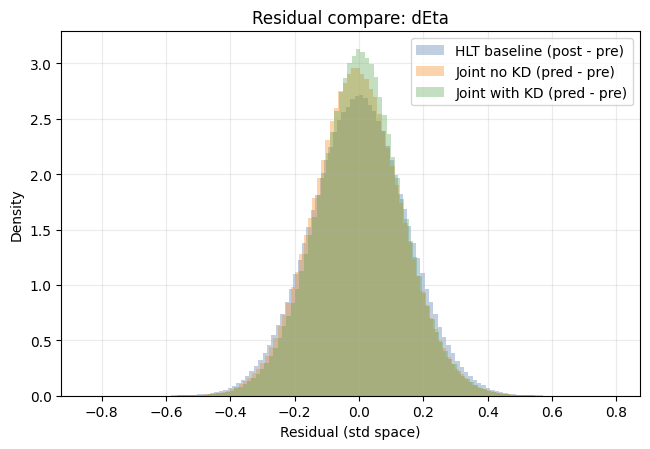

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_dPhi.png


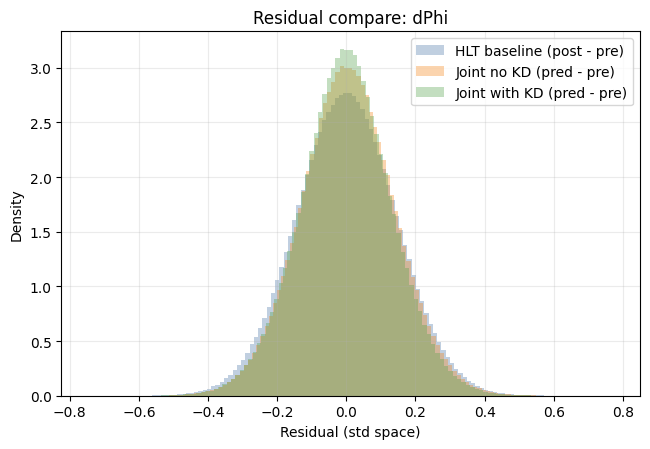

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_pt.png


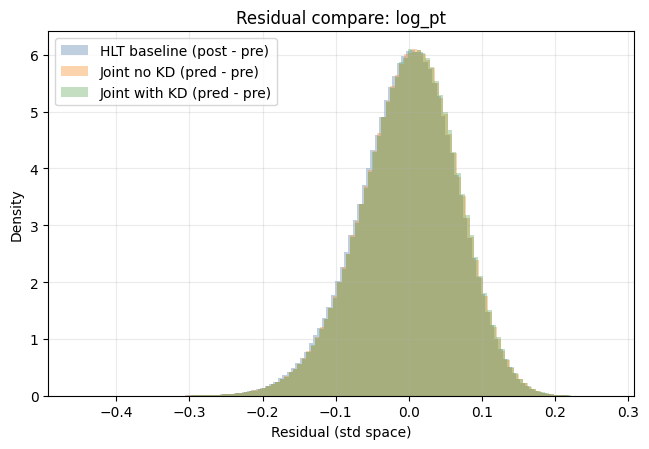

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_E.png


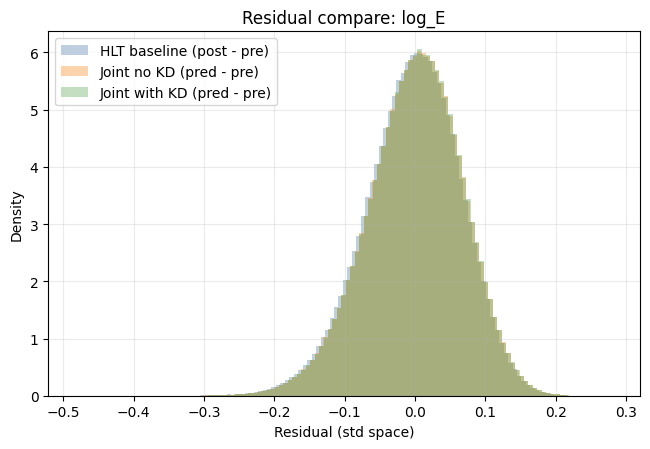

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_pt_rel.png


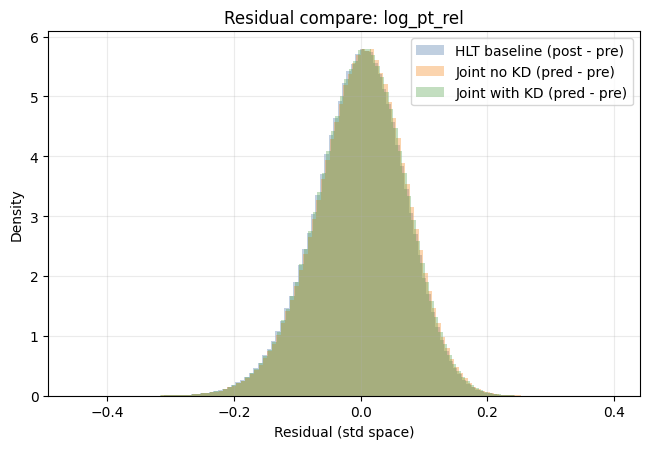

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_E_rel.png


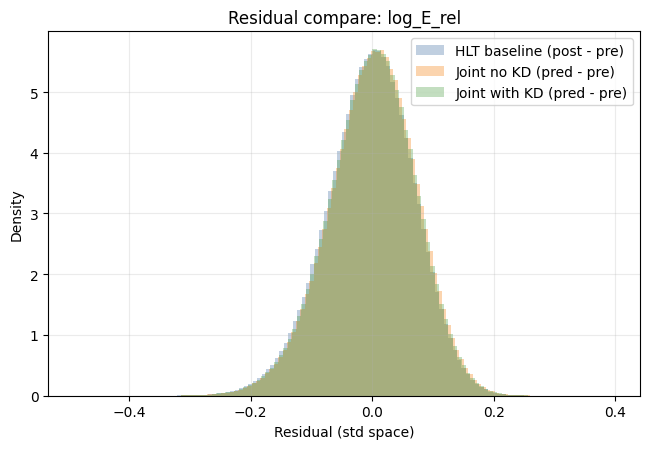

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_dR.png


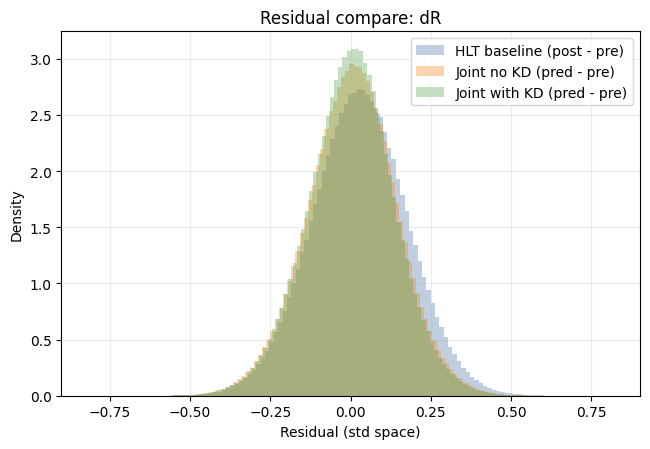


Metrics summary (std space) | split=test | n_tokens=1630900
   feature        method      bias      mae     rmse  abs_p50  abs_p90  abs_p99
      dEta           hlt -0.000556 0.118285 0.148658 0.099482 0.244542 0.385490
      dEta   joint_no_kd -0.005718 0.110289 0.139295 0.091970 0.229416 0.366883
      dEta joint_with_kd  0.002483 0.106326 0.135184 0.087550 0.223087 0.361525
      dPhi           hlt -0.000172 0.115474 0.145006 0.097246 0.238573 0.375467
      dPhi   joint_no_kd  0.004244 0.107649 0.135959 0.089735 0.224016 0.357593
      dPhi joint_with_kd -0.000840 0.104027 0.132105 0.085850 0.217998 0.351853
    log_pt           hlt -0.003360 0.052877 0.066770 0.044331 0.108811 0.177613
    log_pt   joint_no_kd -0.000090 0.052825 0.066539 0.044479 0.108500 0.175295
    log_pt joint_with_kd  0.000221 0.052801 0.066492 0.044469 0.108455 0.175047
     log_E           hlt -0.003796 0.053589 0.067663 0.044937 0.110348 0.179946
     log_E   joint_no_kd -0.000122 0.053506 0.067380 0.0450

,feature,method,bias,mae,rmse,abs_p50,abs_p90,abs_p99
0,dEta,hlt,-0.000556,0.118285,0.148658,0.099482,0.244542,0.385490
1,dEta,joint_no_kd,-0.005718,0.110289,0.139295,0.091970,0.229416,0.366883
2,dEta,joint_with_kd,0.002483,0.106326,0.135184,0.087550,0.223087,0.361525
3,dPhi,hlt,-0.000172,0.115474,0.145006,0.097246,0.238573,0.375467
4,dPhi,joint_no_kd,0.004244,0.107649,0.135959,0.089735,0.224016,0.357593
5,dPhi,joint_with_kd,-0.000840,0.104027,0.132105,0.085850,0.217998,0.351853
6,log_pt,hlt,-0.003360,0.052877,0.066770,0.044331,0.108811,0.177613
7,log_pt,joint_no_kd,-0.000090,0.052825,0.066539,0.044479,0.108500,0.175295
8,log_pt,joint_with_kd,0.000221,0.052801,0.066492,0.044469,0.108455,0.175047
9,log_E,hlt,-0.003796,0.053589,0.067663,0.044937,0.110348,0.179946


In [7]:
# Visualize unsmear reconstruction performance on the test set
import pandas as pd


@torch.no_grad()
def predict_joint_reco(model, loader):
    model.eval()
    outs = []
    for batch in loader:
        x = batch['x'].to(device)
        m = batch['mask'].to(device)
        reco, _logits = model(x, m)
        outs.append(reco.detach().cpu().numpy())
    return np.concatenate(outs, axis=0)


def metric_dict(res_1d: np.ndarray):
    if res_1d.size == 0:
        return {
            'bias': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'abs_p50': np.nan,
            'abs_p90': np.nan,
            'abs_p99': np.nan,
        }
    abs_r = np.abs(res_1d)
    return {
        'bias': float(np.mean(res_1d)),
        'mae': float(np.mean(abs_r)),
        'rmse': float(np.sqrt(np.mean(res_1d ** 2))),
        'abs_p50': float(np.quantile(abs_r, 0.50)),
        'abs_p90': float(np.quantile(abs_r, 0.90)),
        'abs_p99': float(np.quantile(abs_r, 0.99)),
    }


def maybe_wrap_residual(name: str, feat_idx: int, residual: np.ndarray) -> np.ndarray:
    if name == 'dPhi':
        sc = float(feat_stds[feat_idx])
        return tool.wrap_dphi_np(residual * sc) / sc
    return residual


pred_joint_no_kd_reco = predict_joint_reco(joint_model_no_kd, test_loader_joint)
pred_joint_with_kd_reco = predict_joint_reco(joint_model_with_kd, test_loader_joint)

x_test_std = x_joint[test_idx]
y_test_std = y_joint[test_idx]
mask_test = common_mask[test_idx]

residual_sources = {
    'hlt': x_test_std - y_test_std,
    'joint_no_kd': pred_joint_no_kd_reco - y_test_std,
    'joint_with_kd': pred_joint_with_kd_reco - y_test_std,
}
plot_labels = {
    'hlt': 'HLT baseline (post - pre)',
    'joint_no_kd': 'Joint no KD (pred - pre)',
    'joint_with_kd': 'Joint with KD (pred - pre)',
}
plot_colors = {
    'hlt': '#4C78A8',
    'joint_no_kd': '#F58518',
    'joint_with_kd': '#54A24B',
}

metrics_rows = []
for feat_idx, feat_name in enumerate(feat_names):
    plt.figure(figsize=(6.6, 4.6))
    for method_name in ['hlt', 'joint_no_kd', 'joint_with_kd']:
        residual = residual_sources[method_name][..., feat_idx][mask_test]
        residual = maybe_wrap_residual(feat_name, feat_idx, residual)
        plt.hist(
            residual,
            bins=120,
            density=True,
            alpha=0.35,
            label=plot_labels[method_name],
            color=plot_colors[method_name],
        )
        mm = metric_dict(residual)
        metrics_rows.append({
            'feature': feat_name,
            'method': method_name,
            **mm,
        })

    plt.title(f'Residual compare: {feat_name}')
    plt.xlabel('Residual (std space)')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'joint_reco_residual_compare_{feat_name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df[['feature', 'method', 'bias', 'mae', 'rmse', 'abs_p50', 'abs_p90', 'abs_p99']]

print()
print('=' * 100)
print(f'Metrics summary (std space) | split=test | n_tokens={int(mask_test.sum())}')
print('=' * 100)
print(metrics_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

metrics_out = os.path.join(OUT_DIR, 'joint_reco_metrics_summary_test.csv')
metrics_df.to_csv(metrics_out, index=False)
print('Saved table:', metrics_out)

try:
    from IPython.display import display
    display(metrics_df)
except Exception:
    pass


In [ ]:
# Gradient probe analysis from saved train/val probe tables
import json
import pandas as pd

GRAD_PROBE_PREFIXES = {
    'joint_no_kd': os.path.join(REPRESENTATIVE_GRAD_PROBE_DIR, 'joint_no_kd'),
    'joint_with_kd': os.path.join(REPRESENTATIVE_GRAD_PROBE_DIR, 'joint_with_kd'),
}

group_order = ['shared_all', 'input_proj', 'layer_1', 'layer_last']
group_title = {
    'shared_all': 'shared_all',
    'input_proj': 'input_proj',
    'layer_1': 'layer_1',
    'layer_last': 'layer_last',
}
loss_order_all = ['unsmear', 'phys', 'hard', 'kd', 'attn']
loss_color = {
    'unsmear': '#4C78A8',
    'phys': '#9C755F',
    'hard': '#F58518',
    'kd': '#54A24B',
    'attn': '#E45756',
}
pair_order_all = [
    'unsmear_vs_phys',
    'unsmear_vs_hard',
    'unsmear_vs_kd',
    'unsmear_vs_attn',
    'phys_vs_hard',
    'phys_vs_kd',
    'phys_vs_attn',
    'hard_vs_kd',
    'hard_vs_attn',
    'kd_vs_attn',
]
pair_color = {
    'unsmear_vs_phys': '#72B7B2',
    'unsmear_vs_hard': '#E45756',
    'unsmear_vs_kd': '#EECA3B',
    'unsmear_vs_attn': '#B279A2',
    'phys_vs_hard': '#FF9DA6',
    'phys_vs_kd': '#9D755D',
    'phys_vs_attn': '#BAB0AC',
    'hard_vs_kd': '#54A24B',
    'hard_vs_attn': '#F58518',
    'kd_vs_attn': '#4C78A8',
}


def _grad_probe_paths(prefix: str):
    return {
        'scalar': f'{prefix}_scalar_losses.csv',
        'norm': f'{prefix}_grad_norms.csv',
        'cos': f'{prefix}_grad_cosines.csv',
        'feature_scalar': f'{prefix}_feature_scalar_losses.csv',
        'feature_norm': f'{prefix}_feature_grad_norms.csv',
        'feature_cos': f'{prefix}_feature_grad_cosines.csv',
        'meta': f'{prefix}_meta.json',
    }


def _load_grad_probe_tables(prefixes: dict[str, str]):
    scalar_frames = []
    norm_frames = []
    cos_frames = []
    feature_scalar_frames = []
    feature_norm_frames = []
    feature_cos_frames = []
    meta_map = {}
    missing = []
    for model_name, prefix in prefixes.items():
        paths = _grad_probe_paths(prefix)
        need = [paths['scalar'], paths['norm'], paths['cos']]
        missing_now = [p for p in need if not os.path.isfile(p)]
        if missing_now:
            missing.extend(missing_now)
            continue
        scalar_frames.append(pd.read_csv(paths['scalar']))
        norm_frames.append(pd.read_csv(paths['norm']))
        cos_frames.append(pd.read_csv(paths['cos']))
        feature_need = [paths['feature_scalar'], paths['feature_norm'], paths['feature_cos']]
        if all(os.path.isfile(p) for p in feature_need):
            feature_scalar_frames.append(pd.read_csv(paths['feature_scalar']))
            feature_norm_frames.append(pd.read_csv(paths['feature_norm']))
            feature_cos_frames.append(pd.read_csv(paths['feature_cos']))
        if os.path.isfile(paths['meta']):
            with open(paths['meta'], 'r', encoding='utf-8') as f:
                meta_map[model_name] = json.load(f)
        else:
            meta_map[model_name] = {}
    if missing:
        raise FileNotFoundError(
            'Gradient probe tables are missing. If the models were loaded from checkpoints without probe history, rerun training with loading disabled to regenerate them. Missing files: '\
            + ', '.join(sorted(set(missing)))
        )

    feature_scalar_columns = ['model', 'split', 'epoch', 'batch_idx', 'sample_idx', 'total_batches', 'batch_fraction', 'loss_component', 'scalar_loss', 'feature_weight']
    feature_norm_columns = ['model', 'split', 'epoch', 'batch_idx', 'sample_idx', 'total_batches', 'batch_fraction', 'group', 'group_module', 'loss_component', 'grad_norm', 'feature_weight']
    feature_cos_columns = ['model', 'split', 'epoch', 'batch_idx', 'sample_idx', 'total_batches', 'batch_fraction', 'group', 'group_module', 'pair', 'cosine']

    feature_scalar_df = pd.concat(feature_scalar_frames, ignore_index=True) if feature_scalar_frames else pd.DataFrame(columns=feature_scalar_columns)
    feature_norm_df = pd.concat(feature_norm_frames, ignore_index=True) if feature_norm_frames else pd.DataFrame(columns=feature_norm_columns)
    feature_cos_df = pd.concat(feature_cos_frames, ignore_index=True) if feature_cos_frames else pd.DataFrame(columns=feature_cos_columns)
    return (
        pd.concat(scalar_frames, ignore_index=True),
        pd.concat(norm_frames, ignore_index=True),
        pd.concat(cos_frames, ignore_index=True),
        feature_scalar_df,
        feature_norm_df,
        feature_cos_df,
        meta_map,
    )


grad_scalar_df, grad_norms_df, grad_cos_df, grad_feature_scalar_df, grad_feature_norms_df, grad_feature_cos_df, grad_probe_meta = _load_grad_probe_tables(GRAD_PROBE_PREFIXES)

for df in [grad_scalar_df, grad_norms_df, grad_cos_df, grad_feature_scalar_df, grad_feature_norms_df, grad_feature_cos_df]:
    if 'epoch' in df.columns:
        df['epoch'] = df['epoch'].astype(int)
    if 'batch_idx' in df.columns:
        df['batch_idx_1based'] = df['batch_idx'].astype(int) + 1

print('Gradient probe models:', sorted(grad_norms_df['model'].unique().tolist()))
print('Gradient probe splits:', sorted(grad_norms_df['split'].unique().tolist()))
print('Gradient probe epochs:', sorted(grad_norms_df['epoch'].unique().tolist()))
for model_name, meta in grad_probe_meta.items():
    print(f"Meta[{model_name}] =", meta)


MODEL_LOSS_ORDER = {
    'joint_no_kd': ['unsmear', 'phys', 'hard'],
    'joint_with_kd': ['unsmear', 'phys', 'hard', 'kd', 'attn'],
}
MODEL_PAIR_ORDER = {
    'joint_no_kd': ['unsmear_vs_phys', 'unsmear_vs_hard', 'phys_vs_hard'],
    'joint_with_kd': [
        'unsmear_vs_phys',
        'unsmear_vs_hard',
        'unsmear_vs_kd',
        'unsmear_vs_attn',
        'phys_vs_hard',
        'phys_vs_kd',
        'phys_vs_attn',
        'hard_vs_kd',
        'hard_vs_attn',
        'kd_vs_attn',
    ],
}

GRAD_LOSS_WEIGHTS = {
    'joint_no_kd': {
        'unsmear': float(CONFIG['training']['joint_unsmear_weight']),
        'phys': float(CONFIG['training']['joint_unsmear_weight']),
        'hard': float(CONFIG['training']['joint_cls_weight']),
    },
    'joint_with_kd': {
        'unsmear': float(CONFIG['training']['joint_unsmear_weight']),
        'phys': float(CONFIG['training']['joint_unsmear_weight']),
        'hard': float(CONFIG['training']['joint_cls_weight']) * float(1.0 - CONFIG['kd']['alpha_kd']),
        'kd': float(CONFIG['training']['joint_cls_weight']) * float(CONFIG['kd']['alpha_kd']),
        'attn': float(CONFIG['training']['joint_cls_weight']) * float(CONFIG['kd']['alpha_attn']),
    },
}


def _loss_weight(model_name: str, loss_name: str) -> float:
    return float(GRAD_LOSS_WEIGHTS.get(model_name, {}).get(loss_name, 1.0))


def _active_loss_order(model_name: str, df: pd.DataFrame):
    present = set(df['loss_component'].dropna().unique().tolist())
    return [name for name in MODEL_LOSS_ORDER.get(model_name, loss_order_all) if name in present]


def _active_pair_order(model_name: str, df: pd.DataFrame):
    present = set(df['pair'].dropna().unique().tolist())
    return [name for name in MODEL_PAIR_ORDER.get(model_name, pair_order_all) if name in present]


def _active_feature_loss_order(model_name: str, df: pd.DataFrame):
    present = set(df['loss_component'].dropna().unique().tolist())
    return [name for name in FEATURE_LOSS_ORDER.get(model_name, feat_names) if name in present]


def _active_feature_pair_order(model_name: str, df: pd.DataFrame):
    present = set(df['pair'].dropna().unique().tolist())
    return [name for name in FEATURE_PAIR_ORDER.get(model_name, []) if name in present]


grad_norms_df['loss_weight'] = [
    _loss_weight(model_name, loss_name)
    for model_name, loss_name in zip(grad_norms_df['model'], grad_norms_df['loss_component'])
]
grad_norms_df['weighted_grad_norm'] = grad_norms_df['grad_norm'] * grad_norms_df['loss_weight']
print('Applied loss weights:', GRAD_LOSS_WEIGHTS)

FEATURE_LOSS_ORDER = {model_name: list(meta.get('feature_names', feat_names)) for model_name, meta in grad_probe_meta.items()}
FEATURE_WEIGHT_MAP = {
    model_name: {
        feat_name: float(weight)
        for feat_name, weight in zip(
            meta.get('feature_names', feat_names),
            meta.get('feature_loss_weights', [1.0] * len(feat_names)),
        )
    }
    for model_name, meta in grad_probe_meta.items()
}
FEATURE_PAIR_ORDER = {
    model_name: [
        f'{feat_a}_vs_{feat_b}'
        for i, feat_a in enumerate(FEATURE_LOSS_ORDER.get(model_name, feat_names))
        for feat_b in FEATURE_LOSS_ORDER.get(model_name, feat_names)[i + 1:]
    ]
    for model_name in FEATURE_LOSS_ORDER
}
feature_palette = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2', '#B279A2', '#FF9DA6']
feature_color = {
    feat_name: feature_palette[idx % len(feature_palette)]
    for idx, feat_name in enumerate(feat_names)
}
if not grad_feature_norms_df.empty:
    if 'feature_weight' not in grad_feature_norms_df.columns:
        grad_feature_norms_df['feature_weight'] = [
            FEATURE_WEIGHT_MAP.get(model_name, {}).get(loss_name, 1.0)
            for model_name, loss_name in zip(grad_feature_norms_df['model'], grad_feature_norms_df['loss_component'])
        ]
    grad_feature_norms_df['weighted_grad_norm'] = grad_feature_norms_df['grad_norm'] * grad_feature_norms_df['feature_weight']
else:
    grad_feature_norms_df['weighted_grad_norm'] = pd.Series(dtype=float)
print('Applied feature weights:', FEATURE_WEIGHT_MAP)
FEATURE_PROBE_MODELS = sorted(grad_feature_norms_df['model'].dropna().unique().tolist()) if 'model' in grad_feature_norms_df.columns else []
print('Feature probe models:', FEATURE_PROBE_MODELS)


def _save_show(fig, stem: str):
    out = os.path.join(FIG_DIR, stem)
    fig.savefig(out, dpi=170, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()


def plot_epoch_grad_norms(model_name: str, split: str, epoch: int):
    sub_all = grad_norms_df[
        (grad_norms_df['model'] == model_name)
        & (grad_norms_df['split'] == split)
        & (grad_norms_df['epoch'] == int(epoch))
    ].copy()
    if sub_all.empty:
        raise ValueError(f'No grad norm data found for model={model_name}, split={split}, epoch={epoch}')
    active_loss_order = _active_loss_order(model_name, sub_all)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=False)
    axes = axes.reshape(-1)
    for ax, group_name in zip(axes, group_order):
        group_df = sub_all[sub_all['group'] == group_name].copy()
        if group_df.empty:
            ax.axis('off')
            continue
        group_df = group_df.sort_values(['sample_idx', 'batch_idx'])
        for loss_name in active_loss_order:
            loss_df = group_df[group_df['loss_component'] == loss_name].copy()
            if loss_df.empty:
                continue
            ax.plot(
                loss_df['batch_idx_1based'].to_numpy(dtype=float),
                loss_df['weighted_grad_norm'].to_numpy(dtype=float),
                marker='o',
                lw=1.8,
                ms=4,
                color=loss_color.get(loss_name, '#888888'),
                label=f"{loss_name} x {loss_df['loss_weight'].iloc[0]:.3g}",
            )
        ax.set_title(f"{group_title[group_name]}\n{group_df['group_module'].iloc[0]}")
        ax.set_xlabel('Batch index in epoch')
        ax.set_ylabel('Weighted grad norm')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)
    fig.suptitle(f'Weighted gradient norms by sampled batches | model={model_name} | split={split} | epoch={epoch}')
    fig.tight_layout()
    _save_show(fig, f'grad_norm_weighted_epoch_model-{model_name}_split-{split}_epoch-{int(epoch):03d}.png')


def plot_epoch_grad_cosines(model_name: str, split: str, epoch: int):
    sub_all = grad_cos_df[
        (grad_cos_df['model'] == model_name)
        & (grad_cos_df['split'] == split)
        & (grad_cos_df['epoch'] == int(epoch))
    ].copy()
    if sub_all.empty:
        raise ValueError(f'No grad cosine data found for model={model_name}, split={split}, epoch={epoch}')
    active_pair_order = _active_pair_order(model_name, sub_all)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=False)
    axes = axes.reshape(-1)
    for ax, group_name in zip(axes, group_order):
        group_df = sub_all[sub_all['group'] == group_name].copy()
        if group_df.empty:
            ax.axis('off')
            continue
        group_df = group_df.sort_values(['sample_idx', 'batch_idx'])
        for pair_name in active_pair_order:
            pair_df = group_df[group_df['pair'] == pair_name].copy()
            if pair_df.empty:
                continue
            ax.plot(
                pair_df['batch_idx_1based'].to_numpy(dtype=float),
                pair_df['cosine'].to_numpy(dtype=float),
                marker='o',
                lw=1.8,
                ms=4,
                color=pair_color.get(pair_name, '#888888'),
                label=pair_name,
            )
        ax.axhline(0.0, color='black', lw=1.0, alpha=0.6)
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(f"{group_title[group_name]}\n{group_df['group_module'].iloc[0]}")
        ax.set_xlabel('Batch index in epoch')
        ax.set_ylabel('Cosine')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)
    fig.suptitle(f'Gradient cosines by sampled batches | model={model_name} | split={split} | epoch={epoch}')
    fig.tight_layout()
    _save_show(fig, f'grad_cos_epoch_model-{model_name}_split-{split}_epoch-{int(epoch):03d}.png')


def plot_epoch_mean_grad_norms(model_name: str, split: str):
    sub_all = grad_norms_df[
        (grad_norms_df['model'] == model_name)
        & (grad_norms_df['split'] == split)
    ].copy()
    if sub_all.empty:
        raise ValueError(f'No grad norm data found for model={model_name}, split={split}')
    sub_all = sub_all.groupby(['epoch', 'group', 'group_module', 'loss_component'], as_index=False).agg(
        weighted_grad_norm=('weighted_grad_norm', 'mean'),
        loss_weight=('loss_weight', 'first'),
    )
    active_loss_order = _active_loss_order(model_name, sub_all)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True)
    axes = axes.reshape(-1)
    for ax, group_name in zip(axes, group_order):
        group_df = sub_all[sub_all['group'] == group_name].copy()
        if group_df.empty:
            ax.axis('off')
            continue
        for loss_name in active_loss_order:
            loss_df = group_df[group_df['loss_component'] == loss_name].copy().sort_values('epoch')
            if loss_df.empty:
                continue
            ax.plot(
                loss_df['epoch'].to_numpy(dtype=int),
                loss_df['weighted_grad_norm'].to_numpy(dtype=float),
                marker='o',
                lw=2.0,
                ms=4,
                color=loss_color.get(loss_name, '#888888'),
                label=f"{loss_name} x {loss_df['loss_weight'].iloc[0]:.3g}",
            )
        ax.set_title(f"{group_title[group_name]}\n{group_df['group_module'].iloc[0]}")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Mean weighted grad norm')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)
    fig.suptitle(f'Mean weighted gradient norms across epochs | model={model_name} | split={split}')
    fig.tight_layout()
    _save_show(fig, f'grad_norm_weighted_epoch_mean_model-{model_name}_split-{split}.png')


def plot_epoch_mean_grad_cosines(model_name: str, split: str):
    sub_all = grad_cos_df[
        (grad_cos_df['model'] == model_name)
        & (grad_cos_df['split'] == split)
    ].copy()
    if sub_all.empty:
        raise ValueError(f'No grad cosine data found for model={model_name}, split={split}')
    sub_all = sub_all.groupby(['epoch', 'group', 'group_module', 'pair'], as_index=False).agg(
        cosine_mean=('cosine', 'mean'),
        cosine_std=('cosine', 'std'),
    )
    sub_all['cosine_std'] = sub_all['cosine_std'].fillna(0.0)
    active_pair_order = _active_pair_order(model_name, sub_all)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True)
    axes = axes.reshape(-1)
    for ax, group_name in zip(axes, group_order):
        group_df = sub_all[sub_all['group'] == group_name].copy()
        if group_df.empty:
            ax.axis('off')
            continue
        for pair_name in active_pair_order:
            pair_df = group_df[group_df['pair'] == pair_name].copy().sort_values('epoch')
            if pair_df.empty:
                continue
            x = pair_df['epoch'].to_numpy(dtype=int)
            y = pair_df['cosine_mean'].to_numpy(dtype=float)
            y_std = pair_df['cosine_std'].to_numpy(dtype=float)
            color = pair_color.get(pair_name, '#888888')
            ax.plot(
                x,
                y,
                marker='o',
                lw=2.0,
                ms=4,
                color=color,
                label=f'{pair_name} mean',
            )
            ax.fill_between(
                x,
                np.clip(y - y_std, -1.0, 1.0),
                np.clip(y + y_std, -1.0, 1.0),
                color=color,
                alpha=0.18,
                label=f'{pair_name} std',
            )
        ax.axhline(0.0, color='black', lw=1.0, alpha=0.6)
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(f"{group_title[group_name]}\n{group_df['group_module'].iloc[0]}")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Cosine mean ± std')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)
    fig.suptitle(f'Mean and std of gradient cosines across epochs | model={model_name} | split={split}')
    fig.tight_layout()
    _save_show(fig, f'grad_cos_epoch_mean_std_model-{model_name}_split-{split}.png')


def plot_feature_epoch_grad_norms(model_name: str, split: str, epoch: int):
    sub_all = grad_feature_norms_df[
        (grad_feature_norms_df['model'] == model_name)
        & (grad_feature_norms_df['split'] == split)
        & (grad_feature_norms_df['epoch'] == int(epoch))
    ].copy()
    if sub_all.empty:
        raise ValueError(f'No feature grad norm data found for model={model_name}, split={split}, epoch={epoch}')
    active_feature_order = _active_feature_loss_order(model_name, sub_all)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=False)
    axes = axes.reshape(-1)
    for ax, group_name in zip(axes, group_order):
        group_df = sub_all[sub_all['group'] == group_name].copy()
        if group_df.empty:
            ax.axis('off')
            continue
        group_df = group_df.sort_values(['sample_idx', 'batch_idx'])
        for feat_name in active_feature_order:
            feat_df = group_df[group_df['loss_component'] == feat_name].copy()
            if feat_df.empty:
                continue
            ax.plot(
                feat_df['batch_idx_1based'].to_numpy(dtype=float),
                feat_df['weighted_grad_norm'].to_numpy(dtype=float),
                marker='o',
                lw=1.8,
                ms=4,
                color=feature_color.get(feat_name, '#888888'),
                label=f"{feat_name} x {feat_df['feature_weight'].iloc[0]:.3g}",
            )
        ax.set_title(f"{group_title[group_name]}\n{group_df['group_module'].iloc[0]}")
        ax.set_xlabel('Batch index in epoch')
        ax.set_ylabel('Weighted grad norm')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)
    fig.suptitle(f'Weighted feature gradient norms by sampled batches | model={model_name} | split={split} | epoch={epoch}')
    fig.tight_layout()
    _save_show(fig, f'feature_grad_norm_weighted_epoch_model-{model_name}_split-{split}_epoch-{int(epoch):03d}.png')


def plot_feature_epoch_grad_cosines(model_name: str, split: str, epoch: int):
    sub_all = grad_feature_cos_df[
        (grad_feature_cos_df['model'] == model_name)
        & (grad_feature_cos_df['split'] == split)
        & (grad_feature_cos_df['epoch'] == int(epoch))
    ].copy()
    if sub_all.empty:
        raise ValueError(f'No feature grad cosine data found for model={model_name}, split={split}, epoch={epoch}')
    active_pair_order = _active_feature_pair_order(model_name, sub_all)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=False)
    axes = axes.reshape(-1)
    for ax, group_name in zip(axes, group_order):
        group_df = sub_all[sub_all['group'] == group_name].copy()
        if group_df.empty:
            ax.axis('off')
            continue
        group_df = group_df.sort_values(['sample_idx', 'batch_idx'])
        for pair_name in active_pair_order:
            pair_df = group_df[group_df['pair'] == pair_name].copy()
            if pair_df.empty:
                continue
            ax.plot(
                pair_df['batch_idx_1based'].to_numpy(dtype=float),
                pair_df['cosine'].to_numpy(dtype=float),
                marker='o',
                lw=1.8,
                ms=4,
                color=feature_color.get(pair_name.split('_vs_')[0], '#888888'),
                label=pair_name,
            )
        ax.axhline(0.0, color='black', lw=1.0, alpha=0.6)
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(f"{group_title[group_name]}\n{group_df['group_module'].iloc[0]}")
        ax.set_xlabel('Batch index in epoch')
        ax.set_ylabel('Cosine')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=7)
    fig.suptitle(f'Feature gradient cosines by sampled batches | model={model_name} | split={split} | epoch={epoch}')
    fig.tight_layout()
    _save_show(fig, f'feature_grad_cos_epoch_model-{model_name}_split-{split}_epoch-{int(epoch):03d}.png')


def plot_feature_epoch_mean_grad_norms(model_name: str, split: str):
    sub_all = grad_feature_norms_df[
        (grad_feature_norms_df['model'] == model_name)
        & (grad_feature_norms_df['split'] == split)
    ].copy()
    if sub_all.empty:
        raise ValueError(f'No feature grad norm data found for model={model_name}, split={split}')
    sub_all = sub_all.groupby(['epoch', 'group', 'group_module', 'loss_component'], as_index=False).agg(
        weighted_grad_norm=('weighted_grad_norm', 'mean'),
        feature_weight=('feature_weight', 'first'),
    )
    active_feature_order = _active_feature_loss_order(model_name, sub_all)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True)
    axes = axes.reshape(-1)
    for ax, group_name in zip(axes, group_order):
        group_df = sub_all[sub_all['group'] == group_name].copy()
        if group_df.empty:
            ax.axis('off')
            continue
        for feat_name in active_feature_order:
            feat_df = group_df[group_df['loss_component'] == feat_name].copy().sort_values('epoch')
            if feat_df.empty:
                continue
            ax.plot(
                feat_df['epoch'].to_numpy(dtype=int),
                feat_df['weighted_grad_norm'].to_numpy(dtype=float),
                marker='o',
                lw=2.0,
                ms=4,
                color=feature_color.get(feat_name, '#888888'),
                label=f"{feat_name} x {feat_df['feature_weight'].iloc[0]:.3g}",
            )
        ax.set_title(f"{group_title[group_name]}\n{group_df['group_module'].iloc[0]}")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Mean weighted grad norm')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=7)
    fig.suptitle(f'Mean weighted feature gradient norms across epochs | model={model_name} | split={split}')
    fig.tight_layout()
    _save_show(fig, f'feature_grad_norm_weighted_epoch_mean_model-{model_name}_split-{split}.png')


def plot_feature_epoch_mean_grad_cosines(model_name: str, split: str):
    sub_all = grad_feature_cos_df[
        (grad_feature_cos_df['model'] == model_name)
        & (grad_feature_cos_df['split'] == split)
    ].copy()
    if sub_all.empty:
        raise ValueError(f'No feature grad cosine data found for model={model_name}, split={split}')
    sub_all = sub_all.groupby(['epoch', 'group', 'group_module', 'pair'], as_index=False).agg(
        cosine_mean=('cosine', 'mean'),
        cosine_std=('cosine', 'std'),
    )
    sub_all['cosine_std'] = sub_all['cosine_std'].fillna(0.0)
    active_pair_order = _active_feature_pair_order(model_name, sub_all)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True)
    axes = axes.reshape(-1)
    for ax, group_name in zip(axes, group_order):
        group_df = sub_all[sub_all['group'] == group_name].copy()
        if group_df.empty:
            ax.axis('off')
            continue
        for pair_name in active_pair_order:
            pair_df = group_df[group_df['pair'] == pair_name].copy().sort_values('epoch')
            if pair_df.empty:
                continue
            x = pair_df['epoch'].to_numpy(dtype=int)
            y = pair_df['cosine_mean'].to_numpy(dtype=float)
            y_std = pair_df['cosine_std'].to_numpy(dtype=float)
            color = feature_color.get(pair_name.split('_vs_')[0], '#888888')
            ax.plot(
                x,
                y,
                marker='o',
                lw=2.0,
                ms=4,
                color=color,
                label=f'{pair_name} mean',
            )
            ax.fill_between(
                x,
                np.clip(y - y_std, -1.0, 1.0),
                np.clip(y + y_std, -1.0, 1.0),
                color=color,
                alpha=0.18,
                label=f'{pair_name} std',
            )
        ax.axhline(0.0, color='black', lw=1.0, alpha=0.6)
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(f"{group_title[group_name]}\n{group_df['group_module'].iloc[0]}")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Cosine mean ± std')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=7)
    fig.suptitle(f'Mean and std of feature gradient cosines across epochs | model={model_name} | split={split}')
    fig.tight_layout()
    _save_show(fig, f'feature_grad_cos_epoch_mean_std_model-{model_name}_split-{split}.png')


GRAD_PLOT_MODEL = 'joint_with_kd'
GRAD_PLOT_EPOCH = int(sorted(grad_norms_df[grad_norms_df['model'] == GRAD_PLOT_MODEL]['epoch'].unique().tolist())[20])

for split_name in ['train', 'val']:
    plot_epoch_grad_norms(GRAD_PLOT_MODEL, split_name, GRAD_PLOT_EPOCH)
    plot_epoch_grad_cosines(GRAD_PLOT_MODEL, split_name, GRAD_PLOT_EPOCH)
    plot_epoch_mean_grad_norms(GRAD_PLOT_MODEL, split_name)
    plot_epoch_mean_grad_cosines(GRAD_PLOT_MODEL, split_name)
    if GRAD_PLOT_MODEL in FEATURE_PROBE_MODELS:
        plot_feature_epoch_grad_norms(GRAD_PLOT_MODEL, split_name, GRAD_PLOT_EPOCH)
        plot_feature_epoch_grad_cosines(GRAD_PLOT_MODEL, split_name, GRAD_PLOT_EPOCH)
        plot_feature_epoch_mean_grad_norms(GRAD_PLOT_MODEL, split_name)
        plot_feature_epoch_mean_grad_cosines(GRAD_PLOT_MODEL, split_name)
    else:
        print(f'Skip feature-level plots for model={GRAD_PLOT_MODEL}: no feature probe tables found.')


try:
    from IPython.display import display
    display(grad_scalar_df.head())
    display(grad_norms_df.head())
    display(grad_cos_df.head())
    display(grad_feature_scalar_df.head())
    display(grad_feature_norms_df.head())
    display(grad_feature_cos_df.head())
except Exception:
    pass





Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0323\figs\grad_norm_weighted_epoch_model-hlt_kd_split-train_epoch-021.png


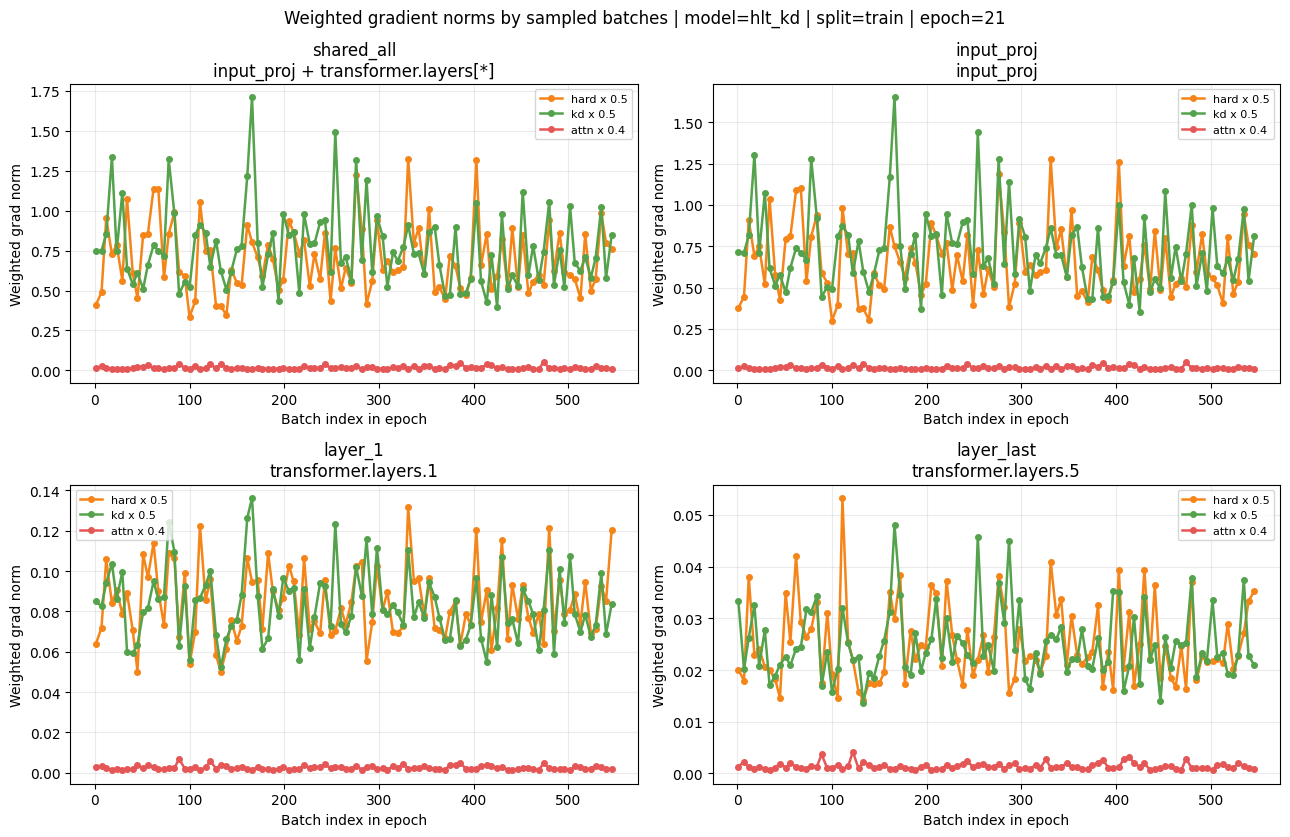

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0323\figs\grad_cos_epoch_model-hlt_kd_split-train_epoch-021.png


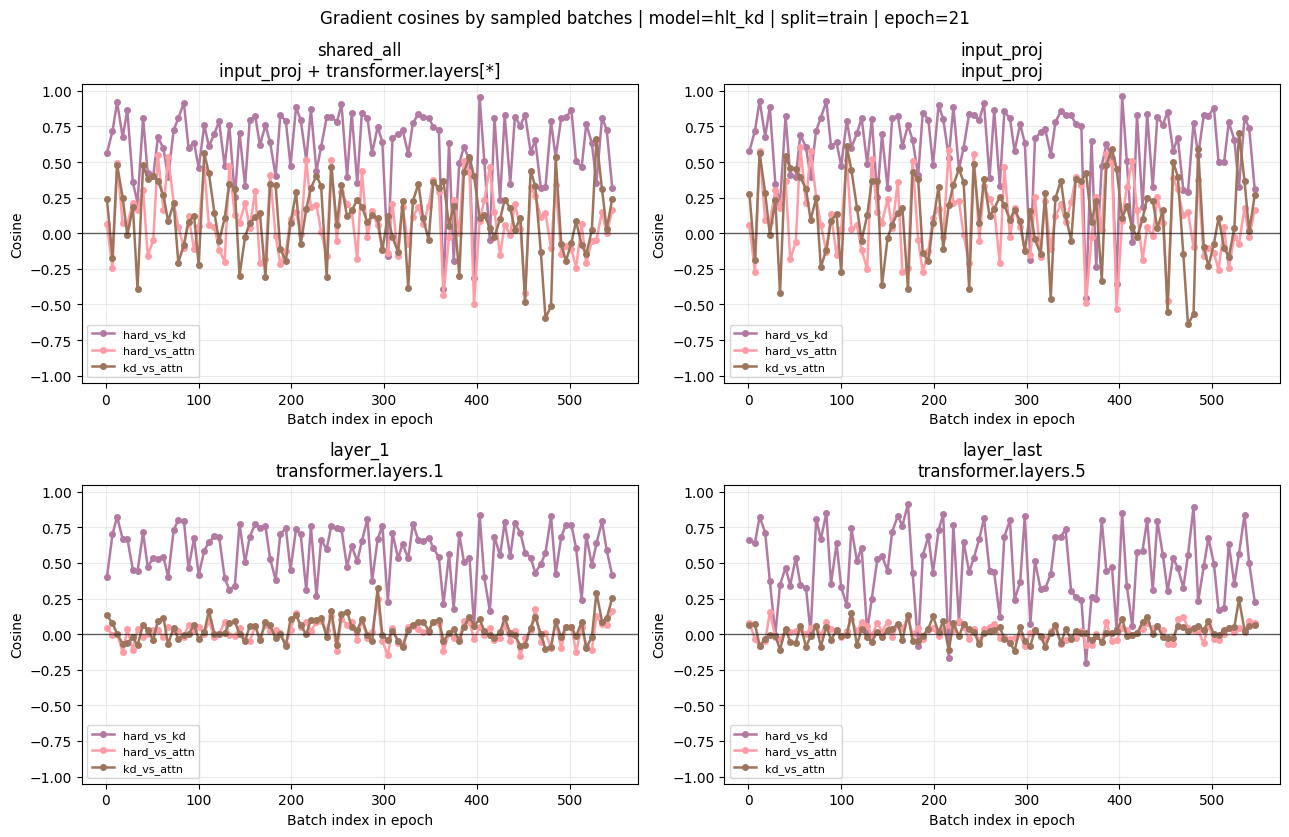

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0323\figs\grad_norm_weighted_epoch_mean_model-hlt_kd_split-train.png


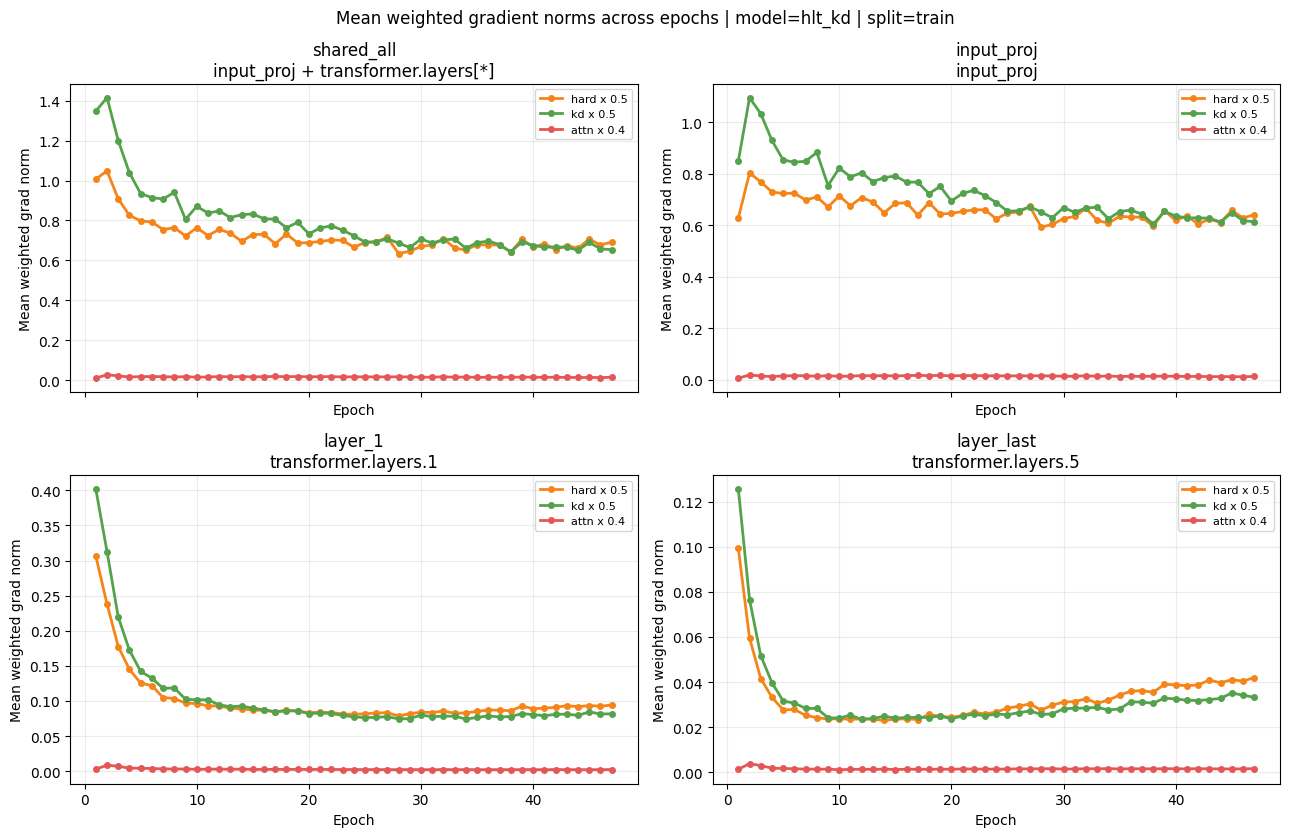

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0323\figs\grad_cos_epoch_mean_std_model-hlt_kd_split-train.png


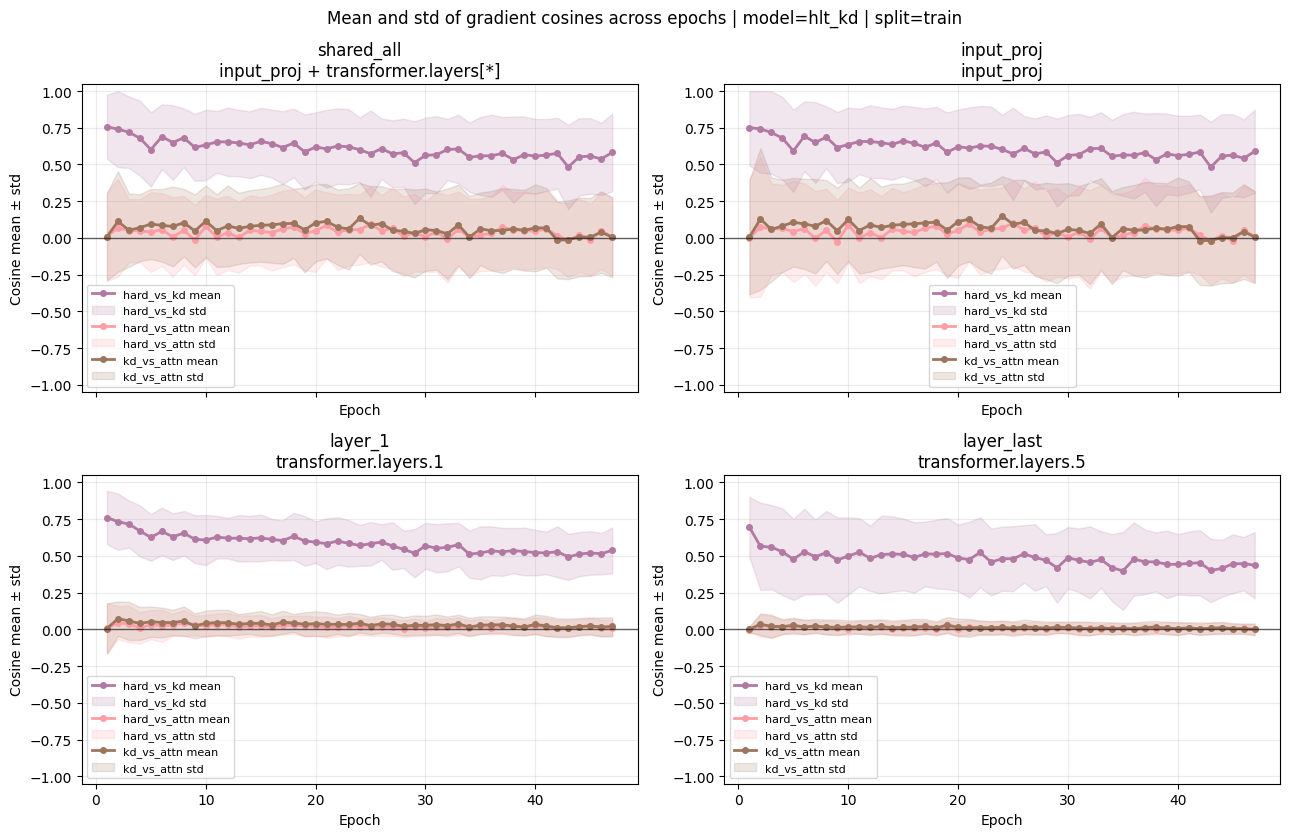

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0323\figs\grad_norm_weighted_epoch_model-hlt_kd_split-val_epoch-021.png


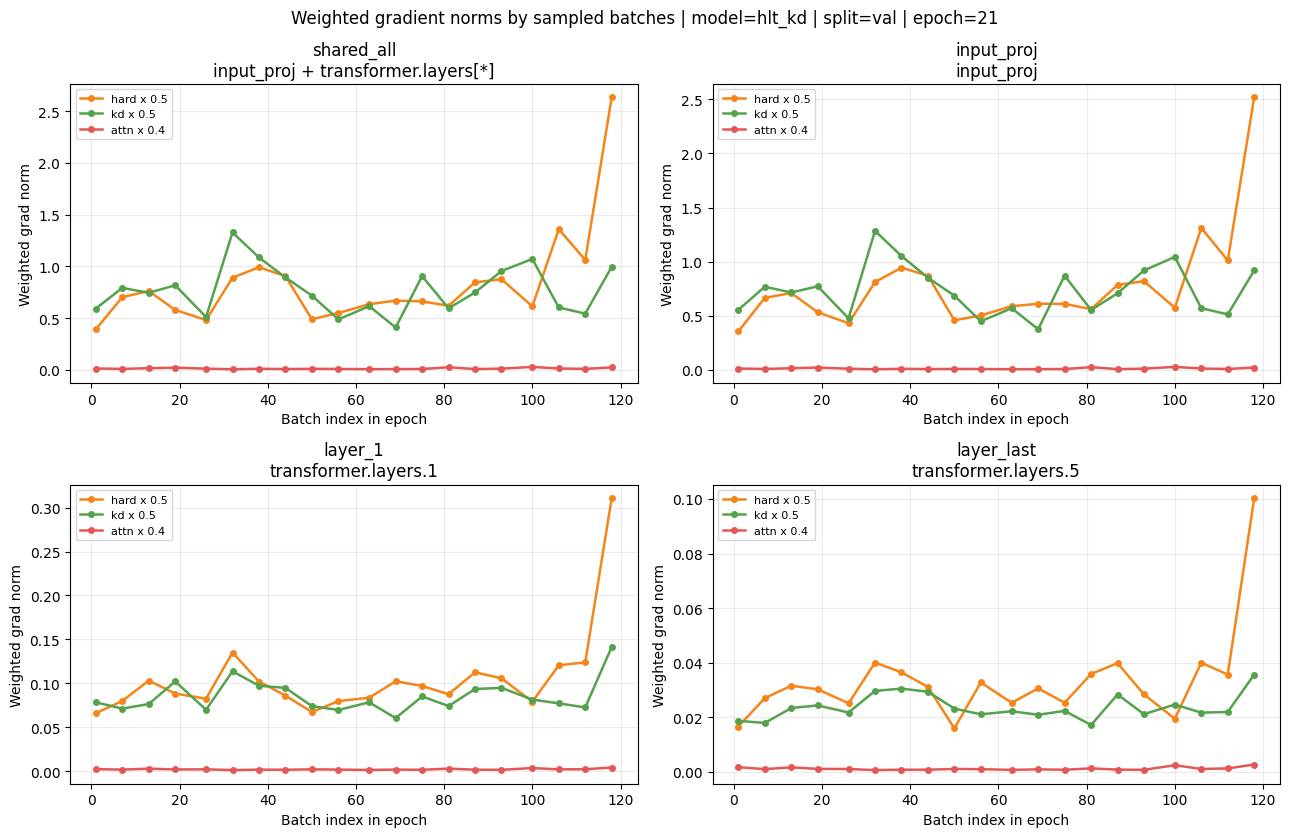

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0323\figs\grad_cos_epoch_model-hlt_kd_split-val_epoch-021.png


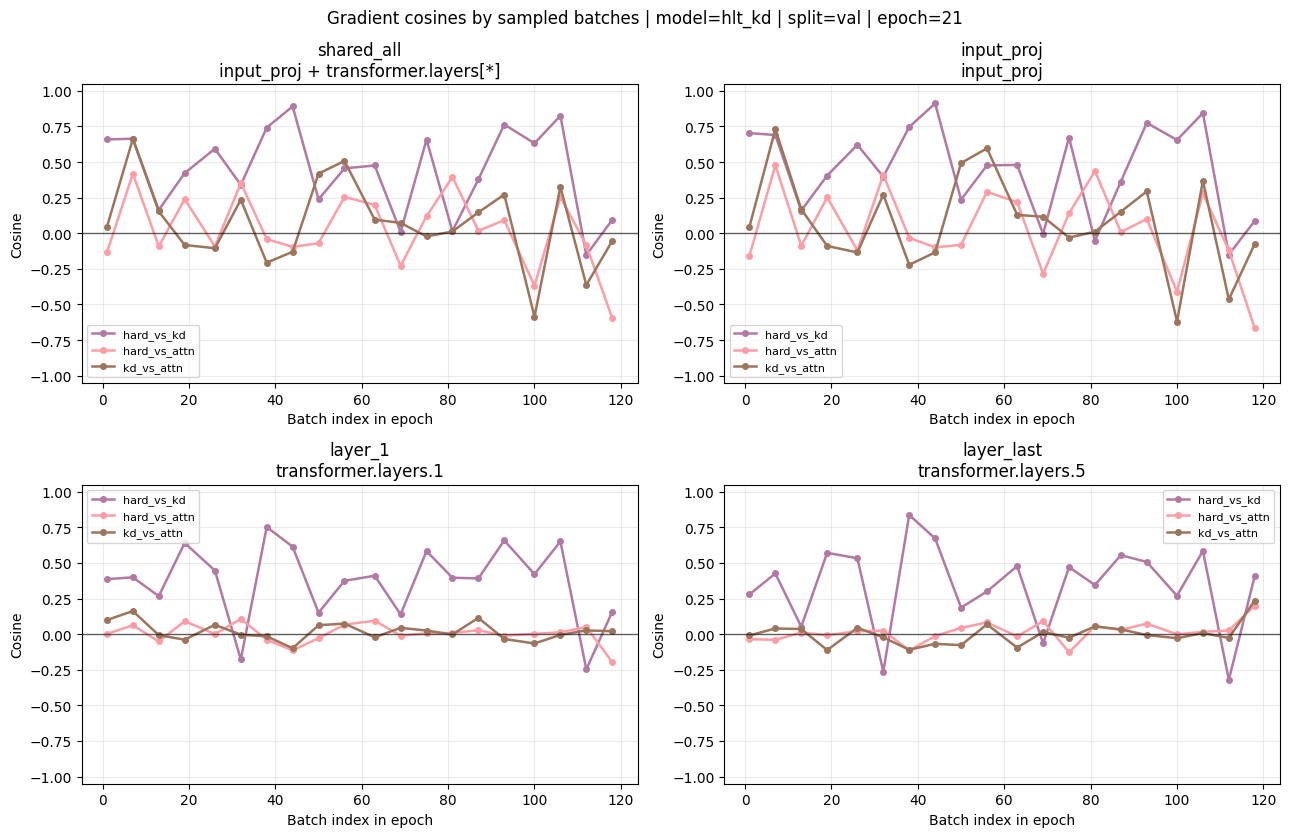

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0323\figs\grad_norm_weighted_epoch_mean_model-hlt_kd_split-val.png


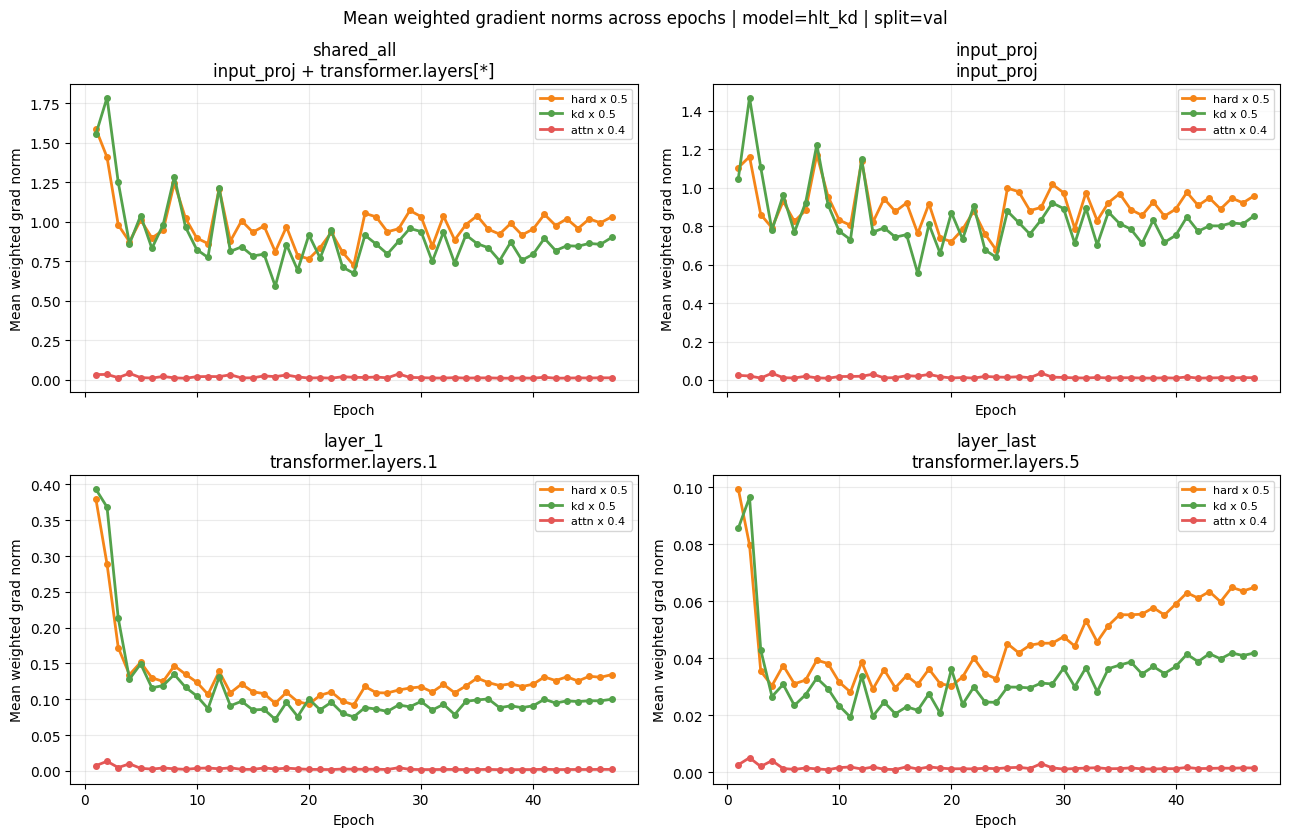

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0323\figs\grad_cos_epoch_mean_std_model-hlt_kd_split-val.png


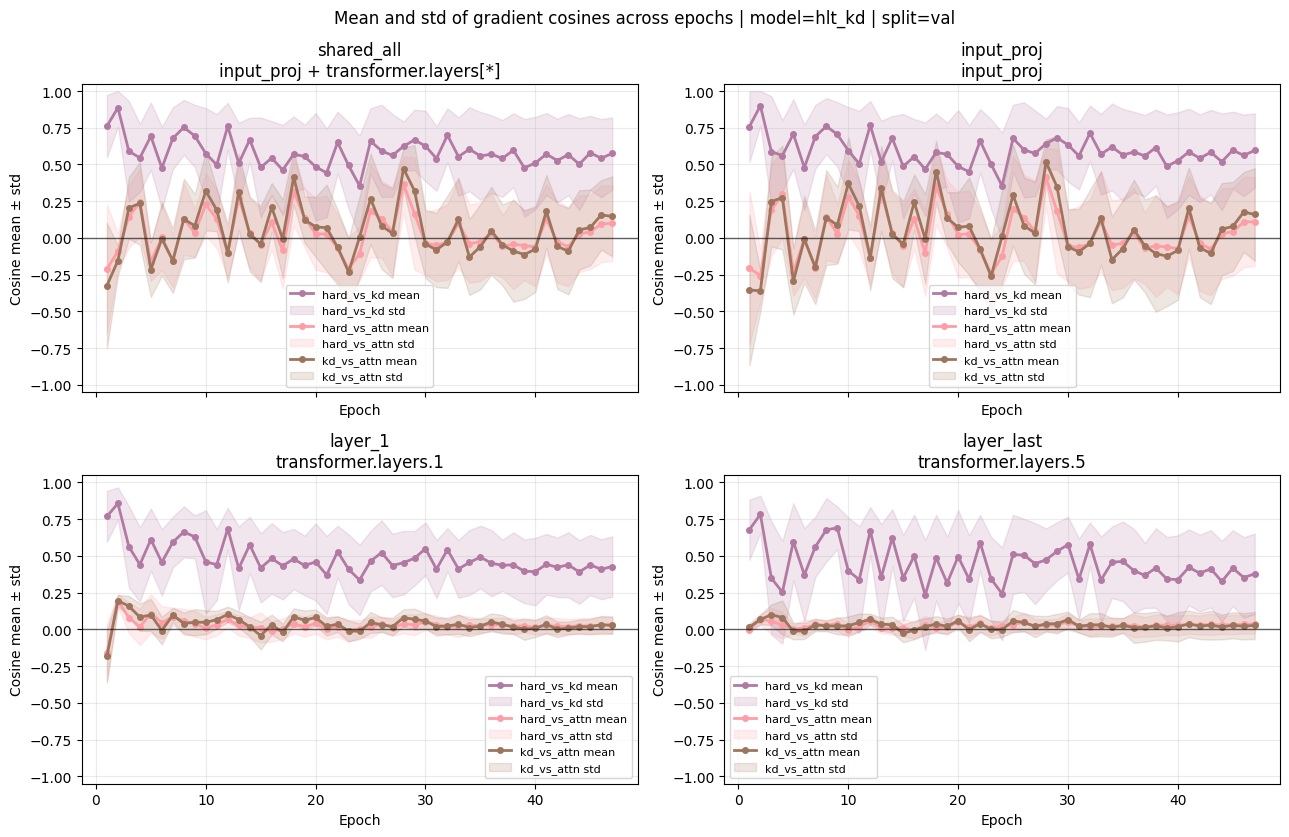

In [5]:
# hlt_kd 现在直接从 external baseline repeat 结果加载，不再在本 notebook 内重新训练。
# 因此外部 baseline 不会在这里生成共享编码器梯度 probe 表，这个单元保留为空说明。
print('Skip hlt_kd gradient plots: external baseline results do not include local gradient probe tables in this notebook.')


In [ ]:
# Load saved checkpoints and inspect top-k pooling attention for random jets from train/val/test
import pandas as pd
from matplotlib import cm
from matplotlib import colors as mcolors

ATTN_SPLIT = 'test'  # 'train' / 'val' / 'test'
ATTN_RANDOM_SEED = 42
ATTN_N_JETS = 6
TOPK_CONST = 12
ATTN_PLOT_STYLE = 'bar'  # 'bar' / 'scatter'
SCATTER_TOPK = 20
ATTN_MODELS = ['offline', 'joint_no_kd', 'joint_with_kd']
ATTN_COLORS = {
    'offline': '#4C78A8',
    'joint_no_kd': '#F58518',
    'joint_with_kd': '#54A24B',
}
ATTN_CKPTS = {
    'offline': teacher_ckpt,
    'joint_no_kd': joint_ckpt_no_kd,
    'joint_with_kd': joint_ckpt_with_kd,
}

SPLIT_INDEX = {
    'train': train_idx,
    'val': val_idx,
    'test': test_idx,
}
SPLIT_FEATURES = {
    'offline': {
        'x': feat_off_std,
        'mask': off_mask,
    },
    'joint_no_kd': {
        'x': x_joint,
        'mask': common_mask,
    },
    'joint_with_kd': {
        'x': x_joint,
        'mask': common_mask,
    },
}


def load_attention_model(model_name: str, ckpt_path: str):
    if model_name == 'offline':
        model = ParticleTransformerKD(**CONFIG['tagger']).to(device)
    elif model_name in ('joint_no_kd', 'joint_with_kd'):
        model = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
    else:
        raise ValueError(f'Unknown attention model: {model_name}')
    tool.load_checkpoint(model, ckpt_path, map_location=device)
    model.eval()
    return model


@torch.no_grad()
def get_attention_from_loaded_model(model_name: str, model, x_np, mask_np, indices):
    x = torch.tensor(x_np[indices], dtype=torch.float32, device=device)
    m = torch.tensor(mask_np[indices], dtype=torch.bool, device=device)
    if model_name == 'offline':
        logits, attn = model(x, m, return_attention=True)
        reco = None
    else:
        reco, logits, attn = model(x, m, return_attention=True)
        reco = reco.detach().cpu().numpy()
    return {
        'logits': logits.squeeze(-1).detach().cpu().numpy(),
        'attn': attn.detach().cpu().numpy(),
        'reco': reco,
    }


def pick_random_attention_jets(split_name: str, n_jets: int, random_seed: int = 42):
    split_idx = np.asarray(SPLIT_INDEX[str(split_name)], dtype=np.int64)
    if split_idx.size == 0:
        raise ValueError(f'Empty split: {split_name}')
    n_pick = min(int(n_jets), int(split_idx.size))
    rs = np.random.RandomState(int(random_seed))
    picked_local = np.sort(rs.choice(split_idx.size, size=n_pick, replace=False)).tolist()
    return picked_local


def _sigmoid_prob(logit: float) -> float:
    return 1.0 / (1.0 + np.exp(-float(logit)))


selected_local_idx = pick_random_attention_jets(ATTN_SPLIT, ATTN_N_JETS, random_seed=ATTN_RANDOM_SEED)
split_global_idx = np.asarray(SPLIT_INDEX[ATTN_SPLIT], dtype=np.int64)

loaded_attention_models = {
    model_name: load_attention_model(model_name, ATTN_CKPTS[model_name])
    for model_name in ATTN_MODELS
}
attention_outputs = {
    model_name: get_attention_from_loaded_model(
        model_name,
        loaded_attention_models[model_name],
        SPLIT_FEATURES[model_name]['x'][split_global_idx],
        SPLIT_FEATURES[model_name]['mask'][split_global_idx],
        selected_local_idx,
    )
    for model_name in ATTN_MODELS
}

print('Attention split:', ATTN_SPLIT)
print('Random seed:', ATTN_RANDOM_SEED)
print('Selected local indices:', selected_local_idx)
print('Selected global indices:', split_global_idx[selected_local_idx].tolist())

for plot_i, local_idx in enumerate(selected_local_idx):
    global_idx = int(split_global_idx[local_idx])
    label_i = int(labels[global_idx])
    weight_i = float(weights[global_idx])
    mask_i = common_mask[global_idx]
    valid_idx = np.where(mask_i)[0]

    attn_map = {
        model_name: attention_outputs[model_name]['attn'][plot_i][valid_idx]
        for model_name in ATTN_MODELS
    }
    prob_map = {
        model_name: _sigmoid_prob(attention_outputs[model_name]['logits'][plot_i])
        for model_name in ATTN_MODELS
    }

    topk_len = min(int(TOPK_CONST), int(len(valid_idx)))
    order_map = {model_name: np.argsort(-attn_map[model_name])[:topk_len] for model_name in ATTN_MODELS}

    print()
    print('=' * 140)
    print(
        f'Attention inspection | split={ATTN_SPLIT} | local={local_idx} | global={global_idx} '
        f'| label={label_i} | weight={weight_i:.4f} | n_valid={len(valid_idx)}'
    )
    print('Predicted probabilities:', {k: round(v, 6) for k, v in prob_map.items()})
    print('=' * 140)

    for model_name in ATTN_MODELS:
        top_order = order_map[model_name]
        top_valid_idx = valid_idx[top_order]
        jet_df = pd.DataFrame({
            'token_rank': np.arange(1, len(top_order) + 1),
            'const_idx': top_valid_idx,
            'attn_weight': attn_map[model_name][top_order],
            'attn_weight_pct': 100.0 * attn_map[model_name][top_order],
        })
        print(f'[{model_name}] top-{len(top_order)} attention weights')
        print(jet_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
        print('-' * 140)

    if str(ATTN_PLOT_STYLE).lower() == 'scatter':
        feat_hlt_i = x_joint[global_idx][valid_idx]
        scatter_len = min(int(SCATTER_TOPK), int(len(valid_idx)))
        scatter_order = np.argsort(-attn_map['joint_with_kd'])[:scatter_len]
        x_scatter = feat_hlt_i[scatter_order, 0]
        y_scatter = feat_hlt_i[scatter_order, 1]
        all_scatter_attn = np.concatenate([attn_map[name][scatter_order] for name in ATTN_MODELS])
        vmin = float(np.min(all_scatter_attn))
        vmax = float(np.max(all_scatter_attn))
        if abs(vmax - vmin) < 1e-12:
            vmax = vmin + 1e-12
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.get_cmap('viridis')

        fig, axes = plt.subplots(1, len(ATTN_MODELS), figsize=(6.8 * len(ATTN_MODELS), 4.8), sharex=True, sharey=True)
        if len(ATTN_MODELS) == 1:
            axes = [axes]
        for ax, model_name in zip(axes, ATTN_MODELS):
            attn_scatter = attn_map[model_name][scatter_order]
            denom = max(float(np.max(attn_scatter)), 1e-12)
            ax.scatter(
                x_scatter,
                y_scatter,
                s=60 + 900 * (attn_scatter / denom),
                c=attn_scatter,
                cmap=cmap,
                norm=norm,
                alpha=0.85,
                edgecolors='black',
                linewidths=0.4,
            )
            for ord_j in scatter_order[: min(10, len(scatter_order))]:
                loc = int(np.where(scatter_order == ord_j)[0][0])
                ax.text(
                    feat_hlt_i[ord_j, 0],
                    feat_hlt_i[ord_j, 1],
                    str(valid_idx[ord_j]),
                    fontsize=8,
                    ha='center',
                    va='center',
                    color='white',
                )
            ax.set_xlabel('HLT dEta (std)')
            ax.set_ylabel('HLT dPhi (std)')
            ax.set_title(f'{model_name} | prob={prob_map[model_name]:.4f}')
            ax.grid(True, alpha=0.25)
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        fig.suptitle(f'Pooling attention scatter | split={ATTN_SPLIT} | global={global_idx}')
        fig.subplots_adjust(right=0.90, top=0.84, wspace=0.28)
        cax = fig.add_axes([0.92, 0.18, 0.015, 0.62])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label('Attention weight')
        out = os.path.join(FIG_DIR, f'attention_scatter_split-{ATTN_SPLIT}_jet_{global_idx}.png')
    else:
        fig, axes = plt.subplots(1, len(ATTN_MODELS), figsize=(6.8 * len(ATTN_MODELS), 4.8))
        if len(ATTN_MODELS) == 1:
            axes = [axes]
        for ax, model_name in zip(axes, ATTN_MODELS):
            top_order = order_map[model_name]
            top_valid_idx = valid_idx[top_order]
            ax.bar(
                np.arange(len(top_order)),
                attn_map[model_name][top_order],
                color=ATTN_COLORS.get(model_name, '#888888'),
                alpha=0.88,
            )
            ax.set_xticks(np.arange(len(top_order)))
            ax.set_xticklabels(top_valid_idx, rotation=35)
            ax.set_xlabel('Constituent index')
            ax.set_ylabel('Attention weight')
            ax.set_title(f'{model_name} | top-{len(top_order)} | prob={prob_map[model_name]:.4f}')
            ax.grid(True, axis='y', alpha=0.25)
        fig.suptitle(f'Pooling attention top-k | split={ATTN_SPLIT} | global={global_idx}')
        fig.tight_layout()
        out = os.path.join(FIG_DIR, f'attention_topk_split-{ATTN_SPLIT}_jet_{global_idx}.png')
    fig.savefig(out, dpi=170, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()
